# Actividad 3 — Análisis del precio de arriendos en Bogotá (estratos 2 a 6)

**Análisis gráfico, estadístico y predictivo de una base de datos de inmuebles**

> **Versión sin estrato 1.** En esta versión del análisis se **excluye el estrato 1**, que solo tenía ~19 registros con precios atípicos (probable error de clasificación). Trabajar sin ese grupo anómalo hace más limpias y confiables las comparaciones entre estratos. Todas las conclusiones aplican a los estratos 2 a 6.

En esta actividad analizamos la base `base_arriendos.csv`, que contiene precios de arriendo de inmuebles en Bogotá junto con características numéricas (área, número de habitaciones, baños, garajes, administración) y categóricas (estrato, zona, antigüedad).

El objetivo es entender **qué determina el precio del arriendo** combinando tres frentes, siguiendo las técnicas de los Casos 6, 7 y 8 de la unidad:

1. **Análisis exploratorio y gráfico** — distribución del precio y su relación con las demás variables.
2. **Análisis estadístico** — descriptivo e inferencial (t-test, ANOVA de uno y dos factores, bootstrapping, correlación de Pearson y chi-cuadrado), validando los supuestos de cada prueba.
3. **Regresión lineal** — un modelo predictivo del precio con diagnóstico de supuestos.

Cerramos con conclusiones que integran los hallazgos y discuten sus limitaciones.

---

## Paso 0 — Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Pruebas de hipótesis (Casos 6 y 7)
from scipy.stats import shapiro, levene, ttest_ind, mannwhitneyu, f_oneway, kruskal, pearsonr, chi2_contingency

# Modelos y ANOVA con statsmodels (Casos 7 y 8)
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.stattools import jarque_bera
import statsmodels.stats.api as sms

sns.set_context('notebook')
sns.set_style('whitegrid')
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
np.random.seed(42)

---
# 1. Carga y limpieza de los datos

Antes de cualquier análisis debemos entender la calidad de la base. Como veremos, contiene **valores atípicos extremos y datos faltantes** que, de no tratarse, distorsionarían por completo cualquier prueba estadística.

In [2]:
arr = pd.read_csv('base_arriendos.csv')
print('Dimensiones:', arr.shape)
arr.head()

Dimensiones: (10001, 12)


,Rent Price,Area (sqm),Area Const (sqm),Bedrooms,Bathrooms,Garages,Admon,estrato,antiguedad,zone,lon,lat
0,2700000,67.33,67.33,3.00,2,1.00,"298,200.00",4.00,Entre 0 y 5 años,Occidental,-74.12,4.66
1,5710000,235.00,235.00,4.00,5,3.00,"790,000.00",6.00,Entre 5 y 10 años,Guaymaral,-74.06,4.80
2,2650000,120.00,120.00,5.00,2,2.00,NaN,3.00,Más de 20 años,Occidental,-74.09,4.69
3,10000000,420.00,420.00,4.00,5,4.00,"960,000.00",5.00,Entre 10 y 20 años,Noroccidente,-74.06,4.76
4,20000000,320.00,320.00,3.00,5,3.00,"3,750,000.00",6.00,Entre 10 y 20 años,Norte,-74.05,4.66


Veamos los tipos de dato y la cantidad de valores faltantes por columna:

In [3]:
print('Tipos de dato:')
print(arr.dtypes)
print('\nValores faltantes por columna:')
print(arr.isna().sum())

Tipos de dato:
Rent Price            int64
Area (sqm)          float64
Area Const (sqm)    float64
Bedrooms            float64
Bathrooms               str
Garages             float64
Admon               float64
estrato             float64
antiguedad              str
zone                    str
lon                 float64
lat                 float64
dtype: object

Valores faltantes por columna:
Rent Price             0
Area (sqm)             2
Area Const (sqm)       1
Bedrooms               1
Bathrooms              1
Garages                1
Admon               1919
estrato                5
antiguedad            13
zone                 497
lon                   56
lat                   56
dtype: int64


Ahora revisemos el resumen estadístico de las variables numéricas. Aquí saltan a la vista los problemas de calidad:

In [4]:
arr.describe().T

,count,mean,std,min,25%,50%,75%,max
Rent Price,"10,001.00","21,317,143.29","338,527,842.37",0.00,"3,087,000.00","6,416,000.00","11,000,000.00","18,000,000,000.00"
Area (sqm),"9,999.00",253.24,"4,805.11",1.00,70.00,144.00,261.00,"480,000.00"
Area Const (sqm),"10,000.00",351.26,"12,102.10",0.00,70.23,146.00,262.00,"1,111,150.00"
Bedrooms,"10,000.00",2.72,1.14,1.00,2.00,3.00,3.00,5.00
Garages,"10,000.00",1.97,1.25,0.00,1.00,2.00,3.00,4.00
Admon,"8,082.00","2,161,207.07","51,189,714.92",0.00,"100,000.00","688,000.00","1,400,000.00","3,500,000,000.00"
estrato,"9,996.00",5.16,1.13,1.00,4.00,6.00,6.00,6.00
lon,"9,945.00",-72.45,10.80,-74.21,-74.06,-74.05,-74.04,0.00
lat,"9,945.00",4.58,0.68,0.00,4.66,4.68,4.70,5.03


**Diagnóstico de calidad de datos.** El resumen anterior revela valores imposibles:

- `Rent Price` llega hasta **18.000 millones** de pesos (un arriendo mensual absurdo) y tiene mínimos de 0.
- `Area (sqm)` alcanza **480.000 m²** y `Area Const` más de un millón.
- `Admon` llega a **3.500 millones**.
- Las coordenadas `lon`/`lat` incluyen ceros (ubicación inválida).

Estos son claramente errores de captura. Además, `Admon` tiene ~1.900 faltantes y `zone` ~500. Procedemos a limpiar con **criterios justificados y conservadores**:

1. Convertir `Bathrooms` a numérico (viene como texto e incluye la categoría `'5+'`, que mapeamos a 5).
2. Eliminar filas con faltantes en las variables clave del análisis (`Rent Price`, `Area (sqm)`, `estrato`, `zone`, `antiguedad`).
3. Filtrar a un **rango realista de mercado**: arriendo entre 500.000 y 60.000.000, y área entre 20 y 1.000 m². Esto descarta los outliers imposibles sin recortar el mercado real de Bogotá.

In [5]:
d = arr.copy()

# 1. Bathrooms a numérico ('5+' -> 5)
d['Bathrooms'] = pd.to_numeric(d['Bathrooms'].replace('5+', '5'), errors='coerce')

# 2. Quitar faltantes en columnas clave
antes = len(d)
d = d.dropna(subset=['Rent Price', 'Area (sqm)', 'estrato', 'zone', 'antiguedad',
                     'Bedrooms', 'Bathrooms', 'Garages'])

# 3. Rango realista de mercado
mask = d['Rent Price'].between(500_000, 60_000_000) & d['Area (sqm)'].between(20, 1000)
d = d[mask].reset_index(drop=True)

# estrato como entero para las gráficas y modelos
d['estrato'] = d['estrato'].astype(int)

# Excluimos el estrato 1: solo ~19 registros y con precios atipicos (probable error de clasificacion)
n_e1 = int((d['estrato'] == 1).sum())
d = d[d['estrato'] != 1].reset_index(drop=True)

print(f'Filas: {antes} -> {len(d)}  (se descartaron {antes - len(d)} por faltantes, valores atipicos o estrato 1)')
print(f'   -> de esas, {n_e1} eran del estrato 1 (excluido por escaso y anomalo)')
print(f'Porcentaje conservado: {len(d)/antes*100:.1f}%')
d.describe().T

Filas: 10001 -> 9284  (se descartaron 717 por faltantes, valores atipicos o estrato 1)
   -> de esas, 19 eran del estrato 1 (excluido por escaso y anomalo)
Porcentaje conservado: 92.8%


,count,mean,std,min,25%,50%,75%,max
Rent Price,"9,284.00","8,015,298.31","6,732,819.49","500,000.00","3,107,500.00","6,300,000.00","10,900,000.00","60,000,000.00"
Area (sqm),"9,284.00",189.29,160.13,20.00,70.00,141.00,256.00,"1,000.00"
Area Const (sqm),"9,284.00",186.92,151.12,0.00,71.24,144.87,260.00,"2,003.00"
Bedrooms,"9,284.00",2.70,1.12,1.00,2.00,3.00,3.00,5.00
Bathrooms,"9,284.00",3.02,1.34,0.00,2.00,3.00,4.00,5.00
Garages,"9,284.00",1.97,1.23,0.00,1.00,2.00,3.00,4.00
Admon,"7,548.00","2,009,067.39","50,712,737.79",0.00,"80,000.00","700,000.00","1,400,000.00","3,500,000,000.00"
estrato,"9,284.00",5.19,1.10,2.00,4.00,6.00,6.00,6.00
lon,"9,245.00",-73.78,4.48,-74.21,-74.06,-74.05,-74.04,0.00
lat,"9,245.00",4.67,0.29,0.00,4.66,4.68,4.70,5.03


Tras la limpieza los rangos ya son coherentes con el mercado real. Creamos también la variable **`log_precio`** (logaritmo natural del arriendo), que usaremos en las pruebas paramétricas y en la regresión. La justificación es estadística y la validamos gráficamente en la siguiente sección: el precio es fuertemente asimétrico, y el logaritmo lo acerca a una distribución simétrica, requisito de las pruebas paramétricas.

In [6]:
d['log_precio'] = np.log(d['Rent Price'])
d['log_area'] = np.log(d['Area (sqm)'])
print('Nueva base lista para el análisis:', d.shape)
print('\nDistribución de estrato:')
print(d['estrato'].value_counts().sort_index())
print('\nDistribución de zona:')
print(d['zone'].value_counts())

Nueva base lista para el análisis: (9284, 14)

Distribución de estrato:
estrato
2     146
3     914
4    1332
5    1571
6    5321
Name: count, dtype: int64

Distribución de zona:
zone
Norte           6043
Noroccidente    1257
Chapinero        684
Occidental       622
Centro           313
Guaymaral        174
Sur              159
Otros             32
Name: count, dtype: int64


> **Decisión: se excluye el estrato 1.** El estrato 1 aparece con muy pocos registros (~19) y con precios atípicamente altos para lo que se esperaría de ese estrato —casi seguro un error de clasificación en la fuente—. Como un grupo tan pequeño y anómalo distorsionaría las comparaciones (boxplots, ANOVA, Tukey) sin aportar información confiable, **lo excluimos del análisis**. Todas las conclusiones de este documento aplican a los **estratos 2 a 6**.

> ### 🧑‍🎓 Explicación para principiantes (para dummies)
>
> **¿Qué hicimos aquí y por qué?** Antes de analizar hay que "limpiar" los datos, como lavar las verduras antes de cocinar. La base traía errores obvios (un arriendo de 18.000 millones de pesos al mes no existe: es un error de digitación). Si dejáramos esos valores locos, arruinarían todos los promedios y las conclusiones.
> **Dos ideas clave:**
> - *Valores faltantes (NaN):* casillas vacías donde no se anotó el dato. Quitamos las filas a las que les falta información importante.
> - *Valores atípicos (outliers):* datos absurdos o extremos. Nos quedamos solo con el rango realista del mercado (arriendos entre 500 mil y 60 millones).
> **¿Y el logaritmo?** Es solo una "regla de medir" distinta que comprime los números grandes. Convierte una distribución muy desbalanceada (muchos baratos, pocos carísimos) en una más pareja y simétrica, que es lo que necesitan las pruebas estadísticas.

---
# 2. Análisis exploratorio y gráfico

Exploramos visualmente cómo se distribuye el precio y cómo se relaciona con las demás variables.

### 2.1 Distribución del precio y justificación de la transformación logarítmica

Comparamos la distribución del precio en su escala original y en escala logarítmica.

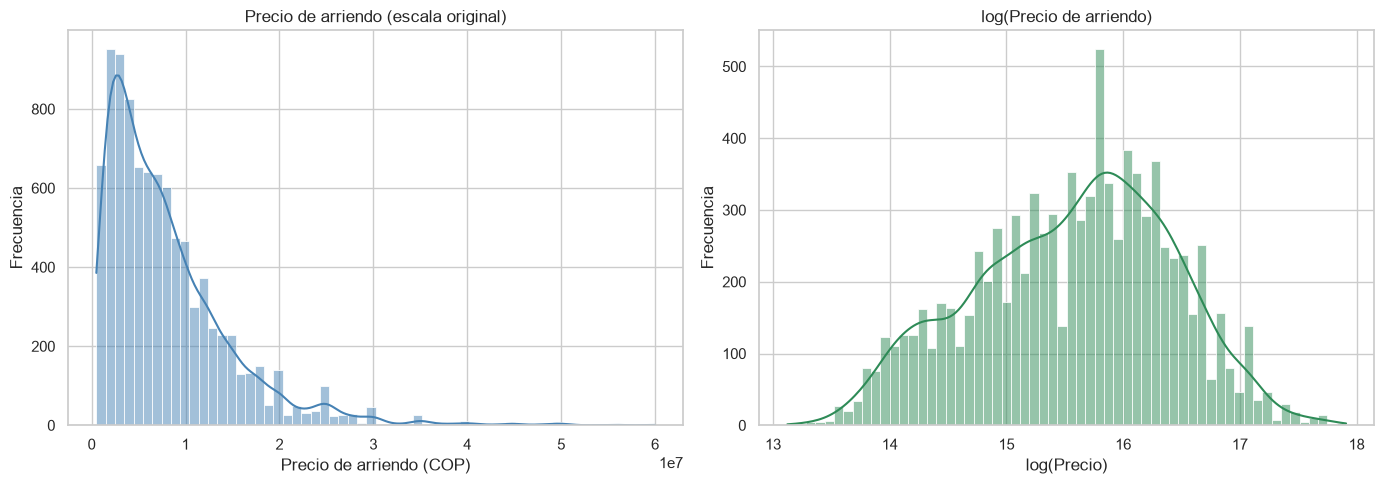

Asimetria (skew) precio original : 2.01
Asimetria (skew) log(precio)     : -0.21


In [7]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(d['Rent Price'], bins=60, kde=True, ax=ax[0], color='steelblue')
ax[0].set_title('Precio de arriendo (escala original)')
ax[0].set_xlabel('Precio de arriendo (COP)')
ax[0].set_ylabel('Frecuencia')

sns.histplot(d['log_precio'], bins=60, kde=True, ax=ax[1], color='seagreen')
ax[1].set_title('log(Precio de arriendo)')
ax[1].set_xlabel('log(Precio)')
ax[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

print(f"Asimetria (skew) precio original : {d['Rent Price'].skew():.2f}")
print(f"Asimetria (skew) log(precio)     : {d['log_precio'].skew():.2f}")

**Interpretación.** El precio original está fuertemente sesgado a la derecha (cola larga de arriendos caros): la asimetría es alta. Al aplicar el logaritmo, la distribución se vuelve **aproximadamente simétrica y acampanada**, mucho más cercana a la normal. Por eso trabajaremos las pruebas paramétricas y la regresión sobre `log_precio`: es la transformación estándar para precios y hace válidos los supuestos de normalidad.

> ### 🧑‍🎓 Explicación para principiantes (para dummies)
>
> **¿Qué es un histograma?** Es una gráfica que cuenta cuántos inmuebles caen en cada rango de precio; las barras altas son los precios más comunes.
> **¿Qué es "asimetría" (skew)?** Mide si la gráfica está "cargada" hacia un lado. La primera gráfica tiene una cola larga a la derecha (pocos arriendos muy caros la estiran). La "campana" ideal (simétrica) es la de la derecha, tras aplicar el logaritmo.
> **¿Por qué importa?** Muchas pruebas estadísticas suponen que los datos forman esa campana simétrica (la "distribución normal"). El logaritmo nos ayuda a lograrla, por eso lo usamos.

### 2.2 Precio por estrato

El estrato socioeconómico es, a priori, uno de los mayores determinantes del precio en Bogotá. Usamos un boxplot (escala log para que se aprecien todos los estratos).

C:\Users\victor.novoa\AppData\Local\Temp\ipykernel_32104\3422778470.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x='estrato', y='Rent Price', ax=ax, palette='viridis')


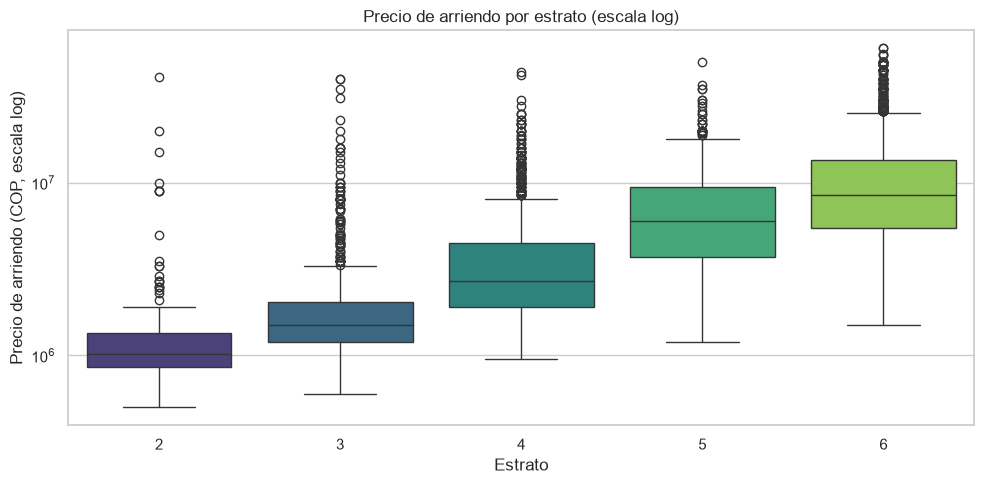

Precio mediano por estrato:
estrato
2   1,016,400.00
3   1,500,000.00
4   2,700,000.00
5   6,000,000.00
6   8,500,000.00
Name: Rent Price, dtype: float64


In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=d, x='estrato', y='Rent Price', ax=ax, palette='viridis')
ax.set_yscale('log')
ax.set_title('Precio de arriendo por estrato (escala log)')
ax.set_xlabel('Estrato')
ax.set_ylabel('Precio de arriendo (COP, escala log)')
plt.tight_layout()
plt.show()

print('Precio mediano por estrato:')
print(d.groupby('estrato')['Rent Price'].median())

**Interpretación.** Se observa una **tendencia creciente clara**: a mayor estrato, mayor precio mediano de arriendo. El salto es especialmente marcado entre estratos 4, 5 y 6. (El estrato 1 fue excluido del análisis, ver sección 1, por lo que la comparación arranca en el estrato 2.)

> ### 🧑‍🎓 Explicación para principiantes (para dummies)
>
> **¿Cómo se lee un boxplot (diagrama de caja)?** Cada caja resume los precios de un estrato:
> - La *línea del medio* es la mediana (el precio "del medio": la mitad cuesta menos, la mitad más).
> - La *caja* contiene el 50% central de los inmuebles.
> - Las *líneas (bigotes)* muestran el rango normal, y los *puntos* sueltos son casos atípicos.
> En pocas palabras: cajas más arriba = arriendos más caros. Aquí se ve una "escalera": subir de estrato sube el precio.

### 2.3 Precio por zona

Ordenamos las zonas por precio mediano para leer el ranking de un vistazo.

C:\Users\victor.novoa\AppData\Local\Temp\ipykernel_32104\1381336961.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x='zone', y='Rent Price', order=orden_zonas, ax=ax, palette='mako')


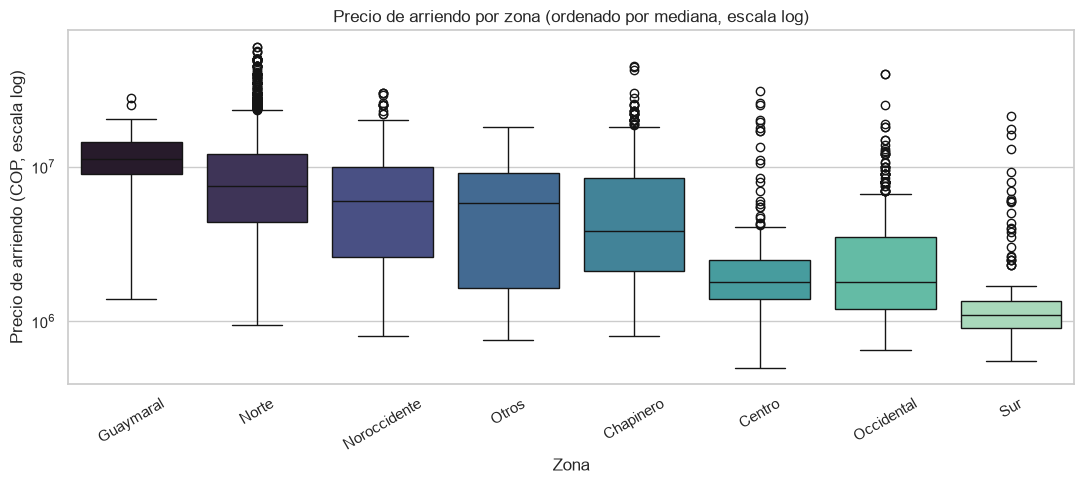

Precio mediano por zona:
zone
Guaymaral      11,230,000.00
Norte           7,500,000.00
Noroccidente    6,000,000.00
Otros           5,850,000.00
Chapinero       3,850,000.00
Centro          1,800,000.00
Occidental      1,800,000.00
Sur             1,100,000.00
Name: Rent Price, dtype: float64


In [9]:
orden_zonas = d.groupby('zone')['Rent Price'].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=d, x='zone', y='Rent Price', order=orden_zonas, ax=ax, palette='mako')
ax.set_yscale('log')
ax.set_title('Precio de arriendo por zona (ordenado por mediana, escala log)')
ax.set_xlabel('Zona')
ax.set_ylabel('Precio de arriendo (COP, escala log)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print('Precio mediano por zona:')
print(d.groupby('zone')['Rent Price'].median().sort_values(ascending=False))

**Interpretación.** Hay una jerarquía geográfica evidente: zonas como **Guaymaral y Norte** concentran los arriendos más caros, mientras que **Sur, Centro y Occidental** son las más económicas. La zona, igual que el estrato, discrimina fuertemente el precio.

> ### 🧑‍🎓 Explicación para principiantes (para dummies)
>
> **La idea sencilla:** aquí comparamos las mismas cajas de antes, pero por zona de la ciudad en vez de por estrato, y las ordenamos de la más cara a la más barata. Es como un ranking: de un vistazo se ve dónde arrendar sale caro (Norte, Guaymaral) y dónde barato (Sur, Centro). La ubicación importa muchísimo en el precio, algo que cualquiera que haya buscado arriendo intuye.

### 2.4 Precio por antigüedad

C:\Users\victor.novoa\AppData\Local\Temp\ipykernel_32104\3304953282.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x='antiguedad', y='Rent Price', order=orden_ant, ax=ax, palette='flare')


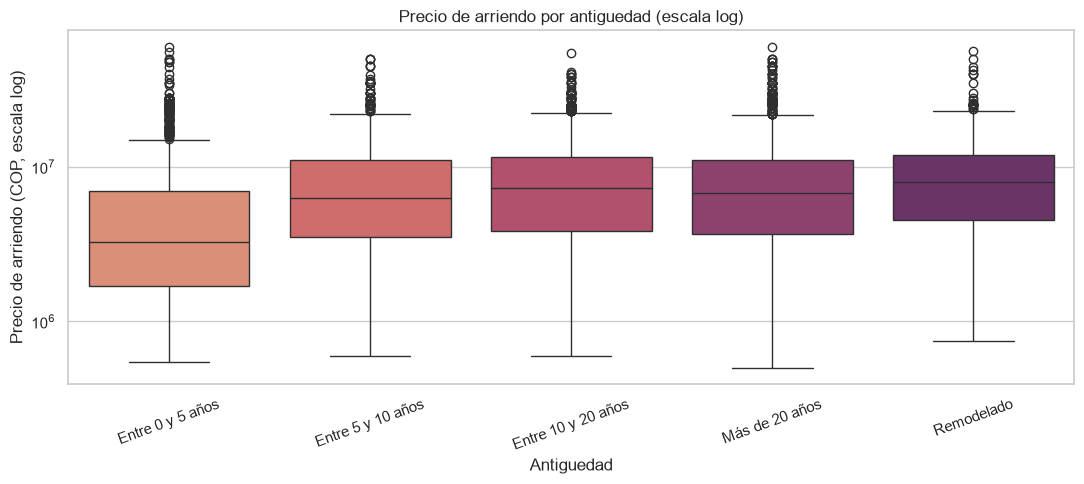

Precio mediano por antiguedad:
antiguedad
Remodelado           7,950,000.00
Entre 10 y 20 años   7,300,000.00
Más de 20 años       6,800,000.00
Entre 5 y 10 años    6,323,000.00
Entre 0 y 5 años     3,262,500.00
Name: Rent Price, dtype: float64


In [10]:
orden_ant = ['Entre 0 y 5 años', 'Entre 5 y 10 años', 'Entre 10 y 20 años', 'Más de 20 años', 'Remodelado']
orden_ant = [x for x in orden_ant if x in d['antiguedad'].unique()]

fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=d, x='antiguedad', y='Rent Price', order=orden_ant, ax=ax, palette='flare')
ax.set_yscale('log')
ax.set_title('Precio de arriendo por antiguedad (escala log)')
ax.set_xlabel('Antiguedad')
ax.set_ylabel('Precio de arriendo (COP, escala log)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

print('Precio mediano por antiguedad:')
print(d.groupby('antiguedad')['Rent Price'].median().sort_values(ascending=False))

**Interpretación.** Las diferencias por antigüedad son **mucho más sutiles** que por estrato o zona. Los inmuebles recientes o remodelados tienden a ser algo más caros, pero los rangos se solapan bastante. Anticipamos que la antigüedad será un factor menos determinante.

> ### 🧑‍🎓 Explicación para principiantes (para dummies)
>
> **En cristiano:** miramos si un apartamento viejo se arrienda por menos que uno nuevo. La respuesta es "un poco, pero no tanto": las cajas están casi a la misma altura y se traslapan mucho. Cuando las cajas se solapan tanto, quiere decir que esa variable (la antigüedad) no cambia el precio de forma tan importante como sí lo hacen el estrato o la zona.

### 2.5 Relación precio vs área

Exploramos la relación entre dos variables continuas con un scatter plot, en escala original y log-log.

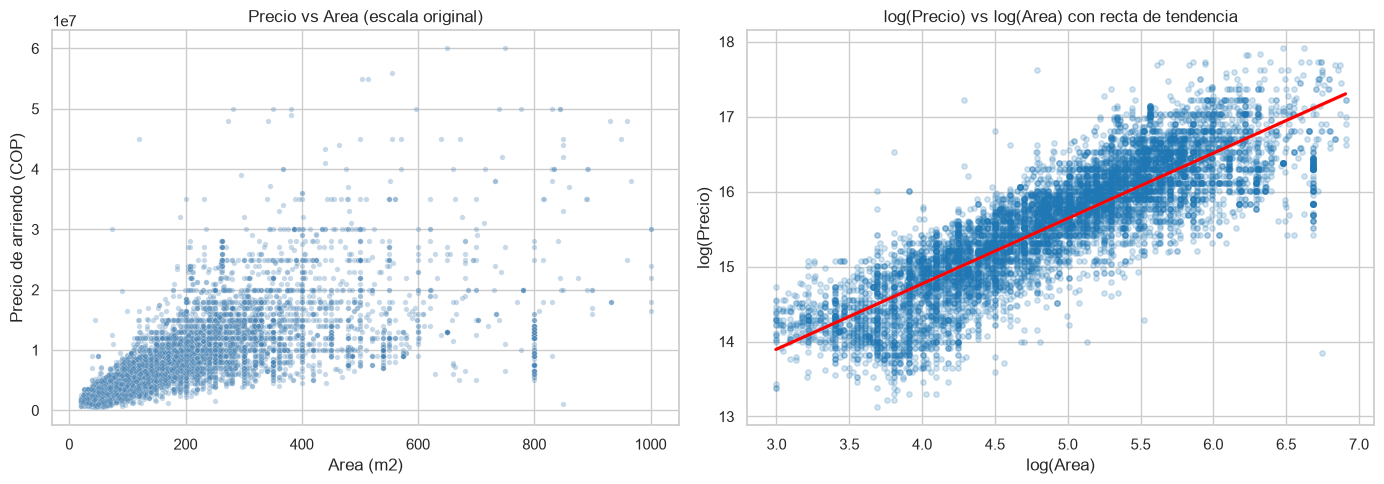

Correlacion Pearson precio-area (original): 0.706
Correlacion Pearson log(precio)-log(area) : 0.855


In [11]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=d, x='Area (sqm)', y='Rent Price', alpha=0.3, s=15, ax=ax[0], color='steelblue')
ax[0].set_title('Precio vs Area (escala original)')
ax[0].set_xlabel('Area (m2)')
ax[0].set_ylabel('Precio de arriendo (COP)')

sns.regplot(data=d, x='log_area', y='log_precio', scatter_kws={'alpha':0.2, 's':15},
            line_kws={'color':'red'}, ax=ax[1])
ax[1].set_title('log(Precio) vs log(Area) con recta de tendencia')
ax[1].set_xlabel('log(Area)')
ax[1].set_ylabel('log(Precio)')

plt.tight_layout()
plt.show()

print(f"Correlacion Pearson precio-area (original): {d['Rent Price'].corr(d['Area (sqm)']):.3f}")
print(f"Correlacion Pearson log(precio)-log(area) : {d['log_precio'].corr(d['log_area']):.3f}")

**Interpretación.** Existe una relación positiva fuerte entre área y precio. En escala log-log la nube se alinea claramente alrededor de una recta y la correlación sube a **~0.85**, lo que sugiere una relación de tipo potencia (elasticidad): duplicar el área multiplica el precio por un factor aproximadamente constante. Esta es otra razón para modelar en escala logarítmica.

> ### 🧑‍🎓 Explicación para principiantes (para dummies)
>
> **¿Qué es un scatter plot (diagrama de dispersión)?** Cada puntito es un inmueble; su posición combina dos datos: área (horizontal) y precio (vertical). Si los puntos suben juntos de izquierda a derecha, es que "a más área, más precio".
> **¿Qué es esa recta roja?** Es la "línea de mejor ajuste": resume la tendencia general de todos los puntos. Mientras más pegados estén los puntos a la recta, más fuerte y predecible es la relación. Aquí están bien alineados: el tamaño es un gran predictor del precio.

### 2.6 Matriz de correlación de variables numéricas

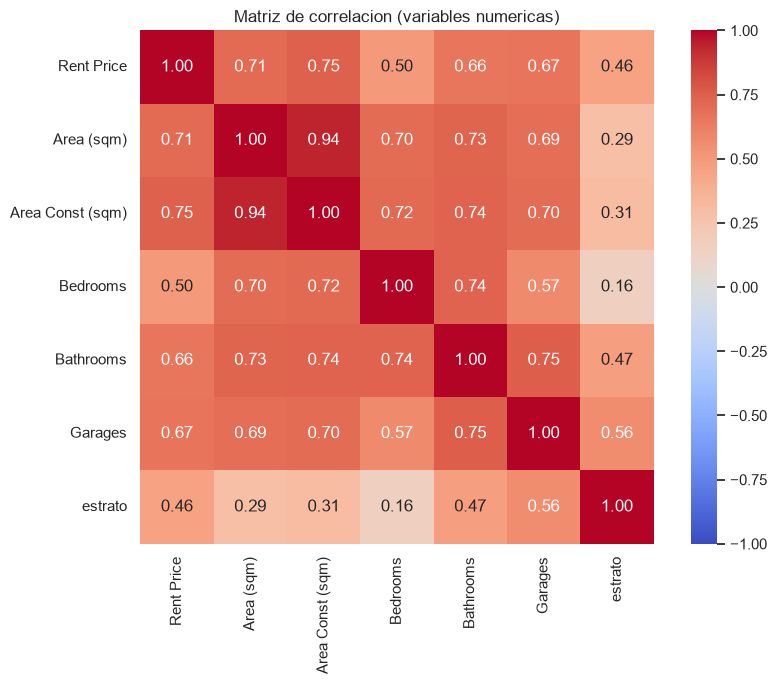

In [12]:
num_cols = ['Rent Price', 'Area (sqm)', 'Area Const (sqm)', 'Bedrooms', 'Bathrooms', 'Garages', 'estrato']
corr = d[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title('Matriz de correlacion (variables numericas)')
plt.tight_layout()
plt.show()

**Interpretación.** El precio se correlaciona positivamente con el **área**, el **estrato**, el número de **baños** y **garajes**. `Area (sqm)` y `Area Const (sqm)` están muy correlacionadas entre sí (miden casi lo mismo), lo que habrá que tener en cuenta para evitar multicolinealidad en la regresión.

> ### 🧑‍🎓 Explicación para principiantes (para dummies)
>
> **¿Qué es esta matriz de colores (heatmap)?** Es una tabla que compara TODAS las variables numéricas entre sí. Cada casilla mide qué tan relacionadas están dos variables, con un número entre -1 y 1:
> - Cerca de **+1** (rojo): suben juntas (más área → más precio).
> - Cerca de **-1** (azul): una sube cuando la otra baja.
> - Cerca de **0** (color pálido): no tienen relación.
> Sirve para ver rápido qué influye en el precio y también para detectar variables "repetidas" (como área y área construida, que miden casi lo mismo).

### 2.7 Precio por metro cuadrado: aislando el "premium" de ubicación

El precio total mezcla dos cosas: **qué tan grande** es el inmueble y **qué tan caro** es cada metro. Al dividir el precio entre el área obtenemos el **precio por m²**, que neutraliza el tamaño y deja ver el valor puro de la ubicación y la calidad.

C:\Users\victor.novoa\AppData\Local\Temp\ipykernel_32104\1774553174.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x='zone', y='precio_m2', order=orden_m2, ax=ax[0], palette='mako')
C:\Users\victor.novoa\AppData\Local\Temp\ipykernel_32104\1774553174.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x='estrato', y='precio_m2', ax=ax[1], palette='viridis')


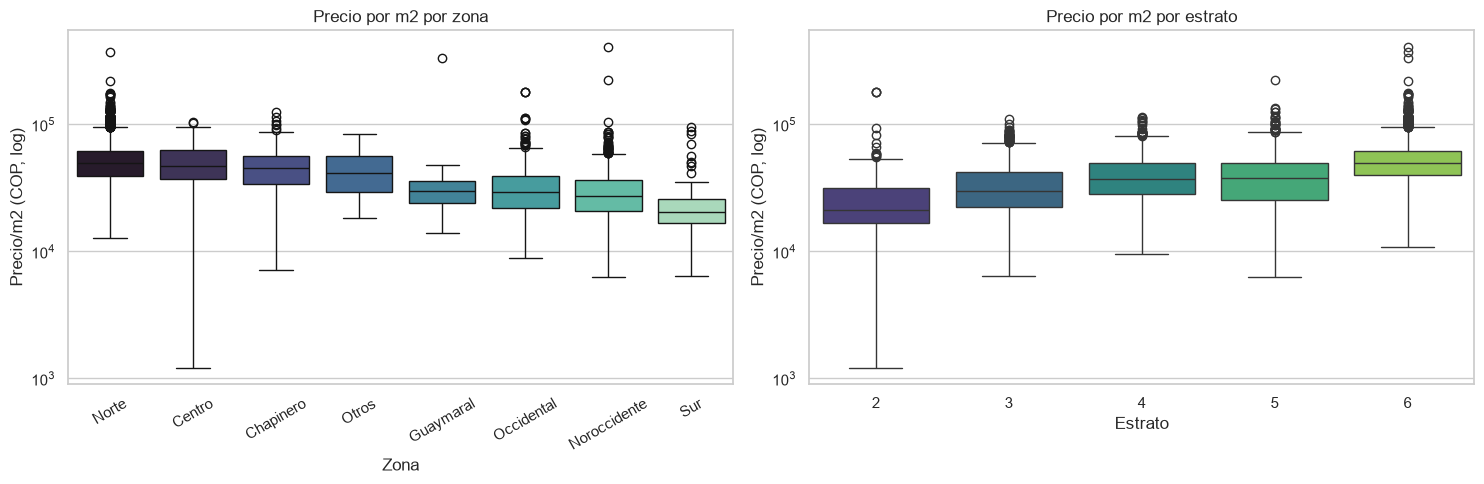

Precio por m2 MEDIANO por zona:
zone
Norte          49,412.00
Centro         47,368.00
Chapinero      45,524.00
Otros          41,507.00
Guaymaral      30,000.00
Occidental     29,361.00
Noroccidente   27,273.00
Sur            20,512.00
Name: precio_m2, dtype: float64


In [13]:
d['precio_m2'] = d['Rent Price'] / d['Area (sqm)']

orden_m2 = d.groupby('zone')['precio_m2'].median().sort_values(ascending=False).index
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(data=d, x='zone', y='precio_m2', order=orden_m2, ax=ax[0], palette='mako')
ax[0].set_yscale('log'); ax[0].set_title('Precio por m2 por zona'); ax[0].set_xlabel('Zona'); ax[0].set_ylabel('Precio/m2 (COP, log)')
ax[0].tick_params(axis='x', rotation=30)
sns.boxplot(data=d, x='estrato', y='precio_m2', ax=ax[1], palette='viridis')
ax[1].set_yscale('log'); ax[1].set_title('Precio por m2 por estrato'); ax[1].set_xlabel('Estrato'); ax[1].set_ylabel('Precio/m2 (COP, log)')
plt.tight_layout(); plt.show()

print('Precio por m2 MEDIANO por zona:')
print(d.groupby('zone')['precio_m2'].median().sort_values(ascending=False).round(0))

**Interpretación.** El ranking de precio/m² **reordena las zonas** frente al precio total y revela algo que el precio bruto ocultaba:

- **Guaymaral**, que era la zona más cara en precio total, cae a la mitad de la tabla en precio/m². Es decir, allí no es que el metro sea carísimo, sino que **los inmuebles son grandes** (casas amplias): se paga mucho por tener mucha área, no por un metro premium.
- **Centro y Chapinero** suben en precio/m²: tienen inmuebles pequeños pero **cada metro es caro** (ubicación central muy valorada).
- **Norte** se mantiene arriba por ambos motivos. **Sur** sigue siendo la más económica por m².

Por estrato, el precio/m² sí crece de forma casi monótona con el estrato, confirmando que a mayor estrato se paga más por cada metro.

> ### 🧑‍🎓 Explicación para principiantes (para dummies)
>
> **¿Qué es el precio por m²?** Es cuánto cuesta cada metro cuadrado de arriendo: se calcula dividiendo el arriendo entre el área. Sirve para comparar "manzanas con manzanas".
> **¿Por qué es tan útil?** Un apartamento puede ser caro por dos razones distintas: porque es **grande** o porque está en un **lugar cotizado**. El precio total las mezcla; el precio por m² separa la ubicación del tamaño.
> **El hallazgo clave:** Guaymaral parecía la zona más cara, pero al mirar el precio por m² baja: sus inmuebles simplemente son grandes. En cambio en el Centro los inmuebles son chiquitos pero cada metro se paga caro. ¡El precio por m² destapa esa diferencia!

### 2.8 La cuota de administración (Admon)

La administración es un costo mensual adicional al arriendo. Veamos cuánto pesa y cómo se relaciona con el precio y el estrato. **Advertencia:** ~1.900 inmuebles no reportan `Admon`; ese análisis usa solo los que sí la tienen.

Inmuebles con administracion valida: 7501 de 9284


C:\Users\victor.novoa\AppData\Local\Temp\ipykernel_32104\4104976420.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dadm, x='estrato', y='admon_pct', ax=ax[0], palette='rocket')


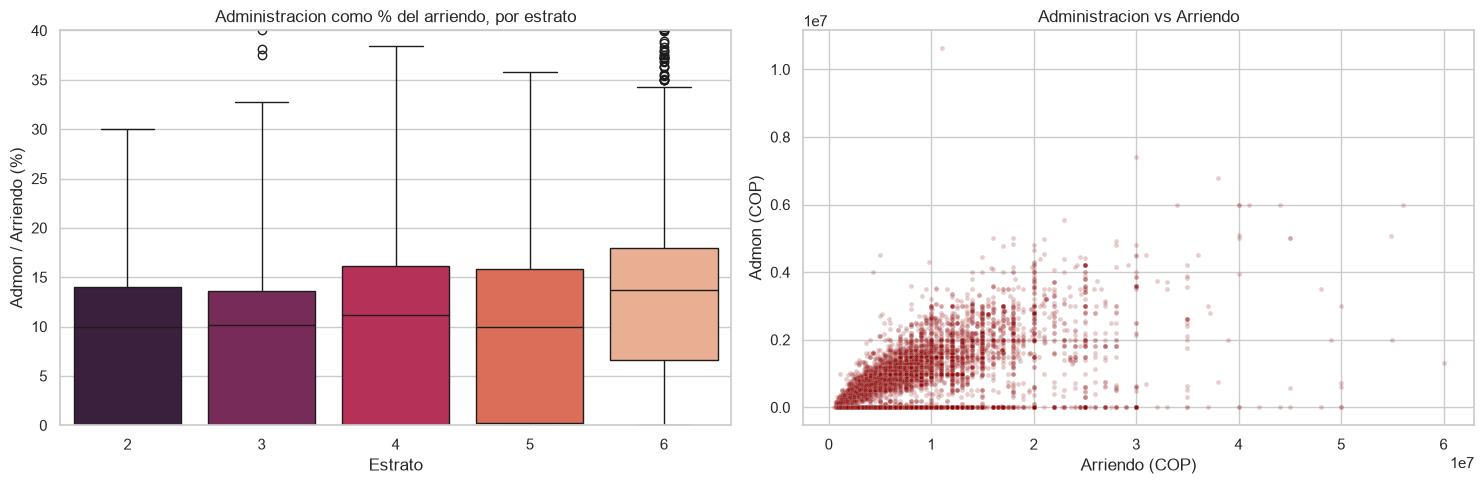

Administracion como % del arriendo (mediana) por estrato:
estrato
2   10.00
3   10.20
4   11.20
5   10.00
6   13.70
Name: admon_pct, dtype: float64

Correlacion Admon-Arriendo: 0.573


In [14]:
dadm = d.dropna(subset=['Admon']).copy()
dadm = dadm[dadm['Admon'] < dadm['Rent Price']]   # la admon deberia ser menor que el arriendo
dadm['admon_pct'] = dadm['Admon'] / dadm['Rent Price'] * 100
print(f'Inmuebles con administracion valida: {len(dadm)} de {len(d)}')

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(data=dadm, x='estrato', y='admon_pct', ax=ax[0], palette='rocket')
ax[0].set_title('Administracion como % del arriendo, por estrato'); ax[0].set_xlabel('Estrato'); ax[0].set_ylabel('Admon / Arriendo (%)')
ax[0].set_ylim(0, 40)
sns.scatterplot(data=dadm, x='Rent Price', y='Admon', alpha=0.2, s=12, ax=ax[1], color='darkred')
ax[1].set_title('Administracion vs Arriendo'); ax[1].set_xlabel('Arriendo (COP)'); ax[1].set_ylabel('Admon (COP)')
plt.tight_layout(); plt.show()

print('Administracion como % del arriendo (mediana) por estrato:')
print(dadm.groupby('estrato')['admon_pct'].median().round(1))
print(f"\nCorrelacion Admon-Arriendo: {dadm['Admon'].corr(dadm['Rent Price']):.3f}")

**Interpretación.** La administración representa típicamente entre el **10% y 14%** del arriendo, y es algo mayor en los estratos altos (6) —edificios con más zonas comunes y servicios—. La correlación positiva (~0.57) confirma que a mayor arriendo, mayor administración, pero **no es una relación perfecta**: hay inmuebles caros con administración baja y viceversa, porque depende del tipo de edificio (conjunto con amenidades vs casa independiente).

> ### 🧑‍🎓 Explicación para principiantes (para dummies)
>
> **¿Qué es la administración (Admon)?** Es la cuota mensual que se paga al conjunto o edificio por mantenimiento, vigilancia y zonas comunes (piscina, gimnasio, portería). Es plata **adicional** al arriendo.
> **¿Qué miramos?** Qué fracción del arriendo representa (aquí, 10-14%) y si sube con el estrato (un poco: los edificios de estrato alto tienen más amenidades que mantener).
> **Nota honesta:** casi 1.900 inmuebles no anotaron su administración, así que este análisis usa solo los que sí la reportaron. Siempre hay que avisar cuando se trabaja con datos incompletos.

### 2.9 Violin plots: viendo la *forma* de la distribución

El boxplot resume la distribución en 5 números, pero oculta su forma. El **violín** dibuja la distribución completa (ancho = cuántos inmuebles hay en ese precio), combinando lo mejor del histograma y del boxplot. Lo usamos para estrato y zona.

C:\Users\victor.novoa\AppData\Local\Temp\ipykernel_32104\337283998.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=d, x='estrato', y='log_precio', ax=ax[0], palette='viridis')
C:\Users\victor.novoa\AppData\Local\Temp\ipykernel_32104\337283998.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=d, x='zone', y='log_precio', order=orden_zonas, ax=ax[1], palette='mako')


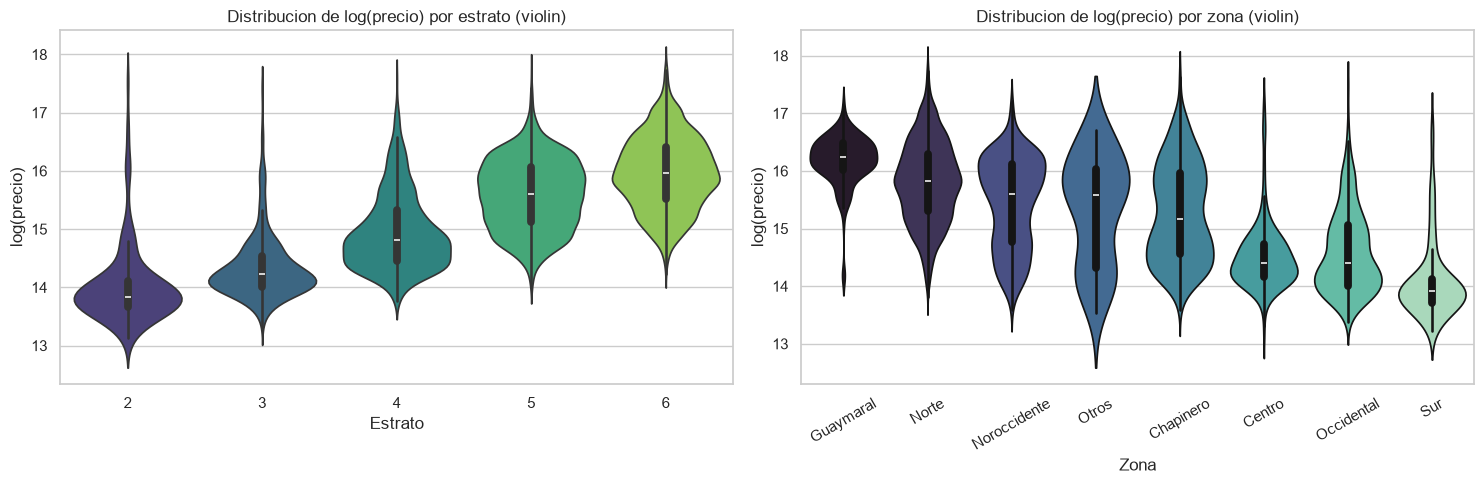

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.violinplot(data=d, x='estrato', y='log_precio', ax=ax[0], palette='viridis')
ax[0].set_title('Distribucion de log(precio) por estrato (violin)')
ax[0].set_xlabel('Estrato'); ax[0].set_ylabel('log(precio)')
sns.violinplot(data=d, x='zone', y='log_precio', order=orden_zonas, ax=ax[1], palette='mako')
ax[1].set_title('Distribucion de log(precio) por zona (violin)')
ax[1].set_xlabel('Zona'); ax[1].set_ylabel('log(precio)'); ax[1].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

**Interpretación.** Los violines confirman la escalera de precios por estrato y zona, pero añaden un detalle: se ve **la forma**. Los estratos altos no solo tienen mayor mediana, sino distribuciones más anchas (más variedad de precios), y algunas zonas muestran distribuciones ligeramente bimodales (dos "jorobas"), señal de submercados dentro de la misma zona.

> ### 🧑‍🎓 Explicación para principiantes (para dummies)
>
> **¿Qué es un violin plot?** Imagina un boxplot al que le pusieron "carne" a los lados: la parte ancha indica dónde se concentran más inmuebles y la angosta donde hay pocos. Es un boxplot + histograma en una sola figura. Donde el violín es gordo, hay muchos arriendos de ese precio; donde es flaco, pocos. Sirve para ver no solo *cuánto* cuesta típicamente, sino *cómo se reparten* los precios.

### 2.10 ¿El precio tiene un patrón geográfico? (mapa con lon/lat)

La base trae coordenadas (`lon`, `lat`) que hasta ahora no habíamos usado. Ubicamos cada inmueble en el mapa y lo coloreamos por precio para ver la geografía del arriendo en Bogotá. Filtramos coordenadas válidas (dentro del rango de la ciudad; recordar que había ceros inválidos).

Inmuebles con coordenada valida: 9,209 de 9,284


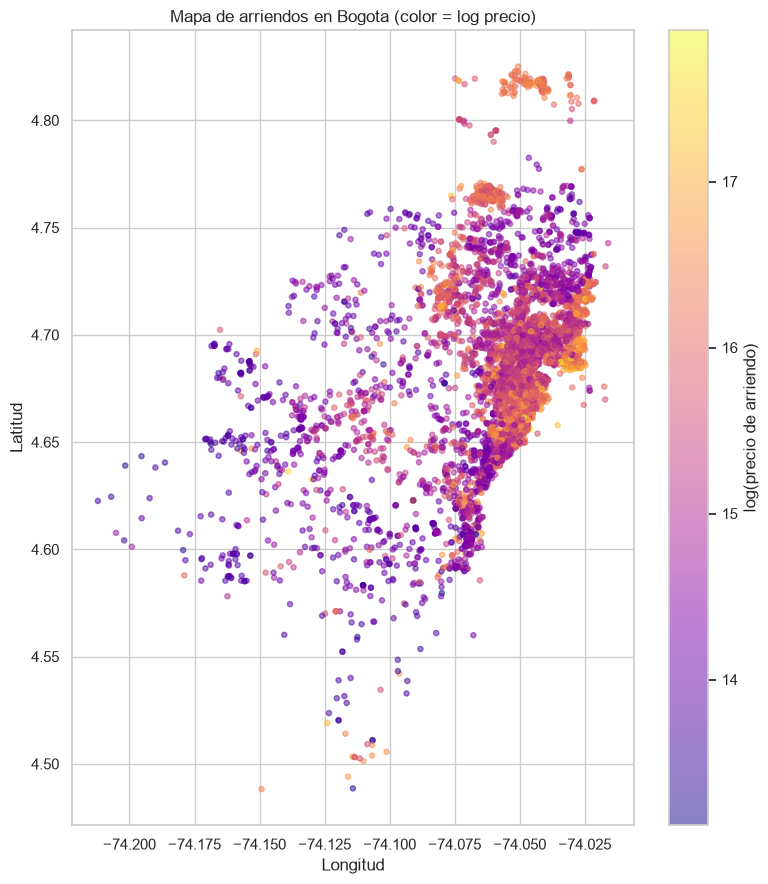

In [16]:
dmapa = d[d['lon'].between(-74.3, -73.9) & d['lat'].between(4.4, 4.9)]
print(f'Inmuebles con coordenada valida: {len(dmapa):,} de {len(d):,}')

fig, ax = plt.subplots(figsize=(8, 9))
sc = ax.scatter(dmapa['lon'], dmapa['lat'], c=np.log(dmapa['Rent Price']),
                cmap='plasma', alpha=0.5, s=14)
ax.set_title('Mapa de arriendos en Bogota (color = log precio)')
ax.set_xlabel('Longitud'); ax.set_ylabel('Latitud')
plt.colorbar(sc, ax=ax, label='log(precio de arriendo)')
plt.tight_layout(); plt.show()

**Interpretación.** El mapa muestra un **gradiente geográfico claro**: los puntos amarillos/claros (arriendos caros) se concentran en el **norte** de la ciudad, y se vuelven morados (más económicos) hacia el **sur** y el occidente. Esto confirma visualmente, sobre el plano real de Bogotá, lo que las pruebas estadísticas dijeron con números: la ubicación es un determinante de primer orden del precio.

> ### 🧑‍🎓 Explicación para principiantes (para dummies)
>
> **¿Qué es este mapa?** Cada puntico es un inmueble puesto en su ubicación real de Bogotá (con su longitud y latitud, como en Google Maps). El color dice el precio: claro = caro, morado = barato.
> **Lo que se ve de un vistazo:** el dinero está en el norte. Es la misma conclusión de las pruebas, pero ahora dibujada sobre el mapa de la ciudad, que a veces convence más que una tabla de números.

---
# 3. Análisis estadístico (descriptivo e inferencial)

Pasamos de lo visual a lo inferencial: **¿son estadísticamente significativas** las diferencias que vimos en las gráficas? Aplicaremos, validando sus supuestos en cada caso:

- t-test entre dos zonas
- ANOVA de una vía (precio por estrato) + post-hoc de Tukey
- ANOVA de dos factores (estrato × antigüedad)
- Bootstrapping (método no paramétrico)
- Correlación de Pearson (precio–área)
- Chi-cuadrado (independencia entre estrato y zona)

Todas las pruebas paramétricas se hacen sobre **`log_precio`** por lo justificado en la sección 2.1.

### 3.1 Estadísticas descriptivas por grupo

In [17]:
print('=== Precio de arriendo por ESTRATO ===')
print(d.groupby('estrato')['Rent Price'].agg(['count', 'mean', 'median', 'std']).round(0))
print('\n=== Precio de arriendo por ZONA ===')
print(d.groupby('zone')['Rent Price'].agg(['count', 'mean', 'median', 'std']).round(0).sort_values('median', ascending=False))

=== Precio de arriendo por ESTRATO ===
         count          mean       median          std
estrato                                               
2          146  1,926,109.00 1,016,400.00 4,042,718.00
3          914  2,222,340.00 1,500,000.00 3,099,278.00
4         1332  4,058,792.00 2,700,000.00 3,947,092.00
5         1571  7,057,179.00 6,000,000.00 4,488,888.00
6         5321 10,450,754.00 8,500,000.00 7,089,048.00

=== Precio de arriendo por ZONA ===
              count          mean        median          std
zone                                                        
Guaymaral       174 11,521,372.00 11,230,000.00 4,113,814.00
Norte          6043  9,360,710.00  7,500,000.00 7,114,050.00
Noroccidente   1257  6,717,522.00  6,000,000.00 4,686,994.00
Otros            32  6,554,859.00  5,850,000.00 5,084,294.00
Chapinero       684  6,128,848.00  3,850,000.00 5,788,080.00
Centro          313  2,649,719.00  1,800,000.00 3,473,064.00
Occidental      622  2,997,944.00  1,800,000.00 3,4

> ### 🧑‍🎓 Explicación para principiantes (para dummies)
>
> **¿Qué son "estadísticas descriptivas"?** Son números que resumen un montón de datos en pocas cifras, para no tener que mirar las 9.303 filas una por una:
> - *count* = cuántos inmuebles hay en el grupo.
> - *mean* (media/promedio) = suma todo y divide; se deja arrastrar por los precios extremos.
> - *median* (mediana) = el valor del medio; más confiable cuando hay valores locos.
> - *std* (desviación estándar) = qué tan dispersos/regados están los precios respecto al promedio.
> Truco: si la media es mucho mayor que la mediana, es señal de que hay pocos inmuebles muy caros jalando el promedio hacia arriba.

**¿Qué variable se mueve más? El coeficiente de variación (CV).** El CV = desviación estándar / media (en %) permite comparar la dispersión de variables con unidades distintas (pesos, m², número de cuartos). Un CV alto significa que esa variable varía mucho de un inmueble a otro.

In [18]:
vars_cv = {'precio': 'Rent Price', 'area': 'Area (sqm)', 'habitaciones': 'Bedrooms',
           'banos': 'Bathrooms', 'garajes': 'Garages', 'estrato': 'estrato', 'precio_m2': 'precio_m2'}
cv = pd.DataFrame({
    'media':  [d[c].mean() for c in vars_cv.values()],
    'std':    [d[c].std()  for c in vars_cv.values()],
}, index=vars_cv.keys())
cv['CV_%'] = (cv['std'] / cv['media'] * 100).round(1)
print('Coeficiente de variacion (ordenado de mayor a menor dispersion):')
print(cv.sort_values('CV_%', ascending=False)[['CV_%']])

Coeficiente de variacion (ordenado de mayor a menor dispersion):
              CV_%
area         84.60
precio       84.00
garajes      62.30
precio_m2    44.90
banos        44.20
habitaciones 41.50
estrato      21.30


**Interpretación.** Las variables que más varían son el **área** y el **precio** (CV ≈ 85%): hay inmuebles diminutos y enormes, baratos y carísimos. Es interesante que el **precio por m²** tiene un CV bastante menor (~45%): al normalizar por tamaño, la dispersión cae casi a la mitad, lo que confirma que buena parte de la variación del precio total se explica simplemente por el tamaño. El **estrato** es la variable más estable (CV ≈ 22%), como corresponde a una escala acotada de 1 a 6.

> ### 🧑‍🎓 Explicación para principiantes (para dummies)
>
> **¿Qué es el coeficiente de variación (CV)?** Es una forma de comparar "qué tan regada" está cada variable, sin importar sus unidades. No puedes comparar directamente la dispersión de los precios (en millones) con la de las habitaciones (1 a 5); el CV los pone a todos en la misma escala (%).
> **Lectura fácil:** CV alto = valores muy dispares entre inmuebles; CV bajo = valores parecidos. Aquí el área y el precio son los más dispares; el estrato, el más parejo.

### 3.2 t-test: ¿difiere el precio entre dos zonas?

Comparamos dos zonas de precio intermedio para que la prueba sea informativa: **Noroccidente vs Chapinero**. La hipótesis nula es que la media de `log_precio` es igual en ambas.

Siguiendo el Caso 6, primero **validamos los supuestos**: normalidad (Shapiro por grupo) y homogeneidad de varianzas (Levene). Según el resultado de Levene elegimos t-test de Student o de Welch, y añadimos un respaldo no paramétrico (Mann-Whitney).

In [19]:
g1 = d[d['zone'] == 'Noroccidente']['log_precio']
g2 = d[d['zone'] == 'Chapinero']['log_precio']
print(f'n Noroccidente = {len(g1)}, n Chapinero = {len(g2)}')

# Supuestos (Shapiro sobre una submuestra si el grupo es grande, por sensibilidad del test)
def shapiro_seguro(x, n=500):
    x = x.sample(min(len(x), n), random_state=1) if len(x) > n else x
    return shapiro(x)[1]

p_n1 = shapiro_seguro(g1); p_n2 = shapiro_seguro(g2)
p_lev = levene(g1, g2)[1]
print(f'Shapiro Noroccidente p = {p_n1:.4f} | Shapiro Chapinero p = {p_n2:.4f}')
print(f'Levene (homogeneidad) p = {p_lev:.4f}')

# t-test (Welch si las varianzas difieren) + Mann-Whitney
equal_var = p_lev >= 0.05
t, p_t = ttest_ind(g1, g2, equal_var=equal_var)
u, p_u = mannwhitneyu(g1, g2)
# Cohen d
sp = np.sqrt(((len(g1)-1)*g1.var(ddof=1) + (len(g2)-1)*g2.var(ddof=1)) / (len(g1)+len(g2)-2))
d_cohen = (g1.mean() - g2.mean()) / sp
tipo = 'Student (var. iguales)' if equal_var else 'Welch (var. distintas)'
print(f'\nt-test {tipo}: t = {t:.3f}, p = {p_t:.2e}')
print(f'Mann-Whitney U (no parametrico): p = {p_u:.2e}')
print(f'Tamano de efecto Cohen d = {d_cohen:.3f}')

n Noroccidente = 1257, n Chapinero = 684
Shapiro Noroccidente p = 0.0000 | Shapiro Chapinero p = 0.0000
Levene (homogeneidad) p = 0.0070

t-test Welch (var. distintas): t = 4.601, p = 4.60e-06
Mann-Whitney U (no parametrico): p = 5.25e-07
Tamano de efecto Cohen d = 0.223


**Interpretación.** El p-valor del t-test es muy inferior a 0.05, de modo que **rechazamos la hipótesis nula**: el precio medio de arriendo difiere significativamente entre Noroccidente y Chapinero. El respaldo no paramétrico (Mann-Whitney) coincide, y el tamaño de efecto confirma que la diferencia no es solo significativa sino relevante. *(La normalidad se rechaza formalmente por el gran tamaño muestral, que hace a Shapiro hipersensible; sin embargo, por el Teorema del Límite Central y la simetría de `log_precio` vista en 2.1, el t-test es robusto, y el Mann-Whitney nos cubre igualmente.)*

> ### 🧑‍🎓 Explicación para principiantes (para dummies)
>
> **¿Qué es un t-test?** Es una prueba para decidir si la diferencia de precio entre dos grupos es **real** o si pudo salir **por pura casualidad** del azar.
> **¿Qué es el p-valor?** Es la pieza más importante. Es la probabilidad de ver esta diferencia si en realidad NO existiera ninguna. La regla universal:
> - **p < 0.05** → la diferencia es real ("significativa"): la aceptamos.
> - **p ≥ 0.05** → pudo ser casualidad: no concluimos nada.
> Aquí p es diminuto (0.000006), así que la diferencia de precio entre las dos zonas es real.
> **¿Y los "supuestos"?** Toda prueba tiene "requisitos de uso" (que los datos sean normales, etc.). Los revisamos ANTES con Shapiro y Levene; si no se cumplen, usamos una prueba alternativa (Mann-Whitney) que no los exige. Por eso corremos las dos: para estar seguros.
> **¿Tamaño de efecto (Cohen d)?** El p-valor dice "hay diferencia", pero no "de qué tamaño". Cohen d mide cuán grande es: es la diferencia práctica, no solo la estadística.

### 3.3 ANOVA de una vía: precio por estrato

Para comparar **más de dos grupos** (los estratos) usamos ANOVA. Hipótesis nula: la media de `log_precio` es igual en todos los estratos. Validamos supuestos (normalidad de residuos y homogeneidad), corremos el ANOVA por las dos vías del Caso 7 (`scipy.f_oneway` y `statsmodels`), añadimos el respaldo no paramétrico **Kruskal-Wallis** y un **post-hoc de Tukey** para saber qué estratos difieren entre sí.

In [20]:
grupos_estrato = [g['log_precio'].values for _, g in d.groupby('estrato')]

# ANOVA con scipy
F, p_anova = f_oneway(*grupos_estrato)
print(f'One-way ANOVA (scipy): F = {F:.2f}, p = {p_anova:.3e}')

# ANOVA con statsmodels + supuestos sobre residuos
modelo_est = ols('log_precio ~ C(estrato)', data=d).fit()
print('\nTabla ANOVA (statsmodels):')
print(sm.stats.anova_lm(modelo_est).round(4))

# Supuestos
p_res = shapiro_seguro(pd.Series(modelo_est.resid))
p_lev_est = levene(*grupos_estrato)[1]
print(f'\nNormalidad residuos (Shapiro) p = {p_res:.4f}')
print(f'Homogeneidad (Levene) p = {p_lev_est:.4f}')

# Respaldo no parametrico
H, p_kw = kruskal(*grupos_estrato)
print(f'Kruskal-Wallis (no parametrico): H = {H:.2f}, p = {p_kw:.3e}')

One-way ANOVA (scipy): F = 1959.48, p = 0.000e+00

Tabla ANOVA (statsmodels):
                 df   sum_sq  mean_sq        F  PR(>F)
C(estrato)     4.00 3,037.98   759.50 1,959.48    0.00
Residual   9,279.00 3,596.54     0.39      NaN     NaN

Normalidad residuos (Shapiro) p = 0.1276
Homogeneidad (Levene) p = 0.0000
Kruskal-Wallis (no parametrico): H = 3751.07, p = 0.000e+00


Como el ANOVA resulta significativo, el post-hoc de Tukey nos dice **entre qué pares de estratos** hay diferencias reales:

In [21]:
tukey = pairwise_tukeyhsd(endog=d['log_precio'], groups=d['estrato'], alpha=0.05)
print(tukey)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj lower  upper  reject
-------------------------------------------------
     2      3   0.3212   0.0 0.1698 0.4726   True
     2      4   0.9226   0.0 0.7745 1.0707   True
     2      5   1.5607   0.0 1.4137 1.7077   True
     2      6   1.9339   0.0 1.7915 2.0764   True
     3      4   0.6014   0.0 0.5284 0.6743   True
     3      5   1.2395   0.0 1.1688 1.3101   True
     3      6   1.6127   0.0 1.5519 1.6735   True
     4      5   0.6381   0.0 0.5748 0.7014   True
     4      6   1.0113   0.0 0.9593 1.0634   True
     5      6   0.3732   0.0 0.3245  0.422   True
-------------------------------------------------


**Interpretación.** El ANOVA es altamente significativo (p ≈ 0): **el estrato sí produce diferencias reales en el precio**. El Kruskal-Wallis lo confirma sin depender de la normalidad. El post-hoc de Tukey muestra que la mayoría de pares de estratos difieren significativamente entre sí (`reject = True`), confirmando la escalera de precios que vimos en el boxplot 2.2.

> ### 🧑‍🎓 Explicación para principiantes (para dummies)
>
> **¿Qué es ANOVA?** El t-test compara SOLO dos grupos. Cuando queremos comparar TRES o más (los 6 estratos a la vez), usamos ANOVA. Responde una pregunta: "¿al menos uno de los estratos tiene un precio promedio distinto de los demás?".
> **El p-valor manda igual:** p < 0.05 significa "sí, hay diferencias reales entre estratos".
> **¿Y el post-hoc de Tukey?** ANOVA solo dice "hay diferencias en alguna parte", pero no dice entre cuáles. Tukey es el detective que compara los estratos de a pares y marca `reject=True` cuando dos estratos de verdad se diferencian. Es como saber que en un grupo alguien es más alto, y luego ir midiendo pareja por pareja para señalar quiénes.
> **Kruskal-Wallis** es el "plan B" de ANOVA para cuando los datos no cumplen los requisitos: llega a la misma conclusión sin exigir la campana normal.

### 3.4 ANOVA de dos factores: estrato × antigüedad

Evaluamos el efecto conjunto de **dos** factores categóricos y su interacción, siguiendo el Caso 7. Nos preguntamos: además del estrato, ¿aporta la antigüedad? ¿el efecto de la antigüedad depende del estrato (interacción)?

In [22]:
modelo_2f = ols('log_precio ~ C(estrato) + C(antiguedad) + C(estrato):C(antiguedad)', data=d).fit()
print('Tabla ANOVA de dos factores:')
print(sm.stats.anova_lm(modelo_2f).round(4))

# Supuestos sobre los residuos del modelo
p_res2 = shapiro_seguro(pd.Series(modelo_2f.resid))
print(f'\nNormalidad de residuos (Shapiro) p = {p_res2:.4f}')

Tabla ANOVA de dos factores:
                               df   sum_sq  mean_sq        F  PR(>F)
C(estrato)                   4.00 3,037.98   759.50 2,025.54    0.00
C(antiguedad)                4.00    59.39    14.85    39.60    0.00
C(estrato):C(antiguedad)    16.00    65.41     4.09    10.90    0.00
Residual                 9,259.00 3,471.74     0.38      NaN     NaN

Normalidad de residuos (Shapiro) p = 0.3282


**Interpretación.** El **estrato** vuelve a ser altamente significativo (y con muchísima más "fuerza explicativa" —columna `sum_sq`— que la antigüedad). La **antigüedad** también resulta significativa como efecto principal, aunque su aporte es mucho menor, como anticipaba el boxplot 2.4. La **interacción** `estrato:antiguedad` también sale significativa (p < 0.05): el efecto de la antigüedad sobre el precio **no es idéntico en todos los estratos** (por ejemplo, remodelar puede pesar distinto en estrato 6 que en estrato 3). Aun así, su aporte (`sum_sq`) es pequeño frente al del estrato.

> ### 🧑‍🎓 Explicación para principiantes (para dummies)
>
> **¿Qué es un ANOVA de dos factores?** Es un ANOVA pero mirando DOS cosas a la vez (estrato Y antigüedad), en lugar de una sola. Nos dice tres cosas:
> - Si el **estrato** influye en el precio (por su lado).
> - Si la **antigüedad** influye (por su lado).
> - Si hay **interacción**: que el efecto de uno dependa del otro. Ejemplo cotidiano: el azúcar y la sal ambos cambian el sabor, pero además "interactúan" (juntos saben distinto que por separado). Aquí, interacción significa que remodelar sube el precio de forma diferente según el estrato.
> Se lee con el mismo p-valor de siempre (< 0.05 = influye). La columna `sum_sq` indica quién pesa más: gana el estrato por mucho.

### 3.5 Bootstrapping: diferencia de medias sin supuestos

El bootstrapping (Caso 6) estima la significancia **sin exigir normalidad ni homogeneidad**. Reconstruimos la distribución de la diferencia de medias **bajo la hipótesis nula** mezclando aleatoriamente las etiquetas de los dos grupos (prueba de permutación), y comparamos con la diferencia real observada.

Diferencia real de medias (log_precio) = 0.1795
p-valor por bootstrapping/permutacion  = 0.0000


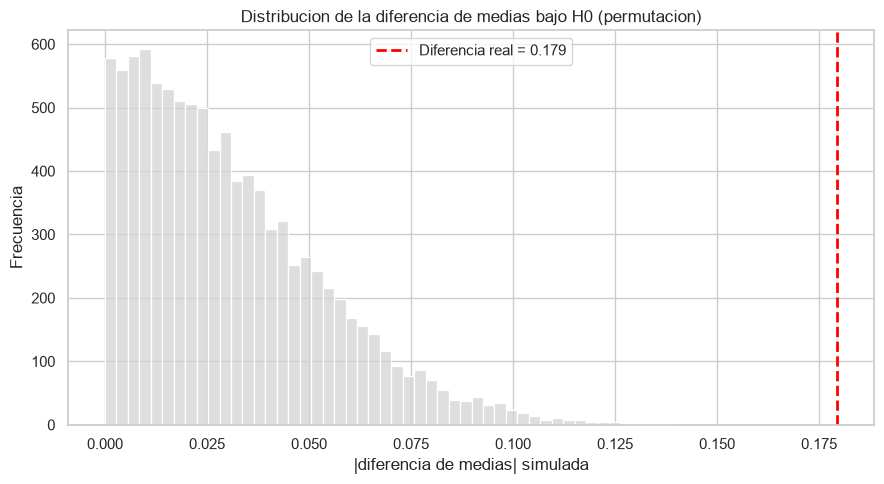

In [23]:
a = d[d['zone'] == 'Noroccidente']['log_precio'].values
b = d[d['zone'] == 'Chapinero']['log_precio'].values
dif_real = np.abs(a.mean() - b.mean())

juntos = np.concatenate([a, b])
n_a = len(a)
n_boot = 10000
difs = np.empty(n_boot)
for i in range(n_boot):
    perm = np.random.permutation(juntos)
    difs[i] = np.abs(perm[:n_a].mean() - perm[n_a:].mean())

p_boot = np.sum(difs >= dif_real) / n_boot
print(f'Diferencia real de medias (log_precio) = {dif_real:.4f}')
print(f'p-valor por bootstrapping/permutacion  = {p_boot:.4f}')

fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(difs, bins=50, ax=ax, color='lightgray')
ax.axvline(dif_real, color='red', linestyle='--', linewidth=2, label=f'Diferencia real = {dif_real:.3f}')
ax.set_title('Distribucion de la diferencia de medias bajo H0 (permutacion)')
ax.set_xlabel('|diferencia de medias| simulada')
ax.set_ylabel('Frecuencia')
ax.legend()
plt.tight_layout()
plt.show()

**Interpretación.** La diferencia real (línea roja) queda **muy lejos, a la derecha** de toda la distribución simulada bajo la hipótesis nula: prácticamente ninguna permutación aleatoria alcanza esa diferencia, por lo que el p-valor es ~0. Esto **confirma el resultado del t-test (3.2) con un método que no depende de ningún supuesto paramétrico**, dándonos mayor confianza en la conclusión.

> ### 🧑‍🎓 Explicación para principiantes (para dummies)
>
> **¿Qué es el bootstrapping / permutación?** Es una forma de comprobar resultados "haciendo trampa a la suerte" con el computador, sin fórmulas complicadas ni requisitos.
> **La idea con una analogía:** tenemos dos grupos de precios (dos zonas) y vemos que sus promedios difieren. Nos preguntamos: ¿y si fuera casualidad? Para averiguarlo, revolvemos TODOS los precios en una sola bolsa, los repartimos al azar en dos montones nuevos 10.000 veces, y anotamos la diferencia que sale cada vez SOLO por azar.
> **Cómo se lee la gráfica:** la montaña gris son esas 10.000 diferencias al azar. La línea roja es la diferencia REAL que observamos. Si la línea roja queda fuera de la montaña (como aquí), significa que el azar casi nunca produce algo así → la diferencia es real. El p-valor es simplemente qué fracción del azar igualó o superó lo real.

### 3.6 Correlación de Pearson: precio vs área

Cuantificamos formalmente la fuerza y significancia de la relación precio–área (en log-log).

In [24]:
r, p_r = pearsonr(d['log_area'], d['log_precio'])
print(f'Correlacion de Pearson log(area)-log(precio): r = {r:.3f}, p = {p_r:.2e}')

Correlacion de Pearson log(area)-log(precio): r = 0.855, p = 0.00e+00


**Interpretación.** La correlación es **fuerte y positiva (r ≈ 0.85)** y altamente significativa (p ≈ 0): a mayor área, mayor precio, de forma muy consistente. El área es el predictor continuo más importante del precio.

> ### 🧑‍🎓 Explicación para principiantes (para dummies)
>
> **¿Qué es la correlación de Pearson (r)?** Un solo número, entre -1 y 1, que mide qué tan "de la mano" van dos variables:
> - **r = 1**: relación perfecta positiva (cuando una sube, la otra siempre sube).
> - **r = 0**: no tienen nada que ver.
> - **r = -1**: perfecta inversa (una sube, la otra baja).
> Aquí r ≈ 0.85 es muy alto: área y precio van casi siempre juntos. El p-valor, como siempre, confirma que no es casualidad. **Ojo:** correlación NO es causalidad (que dos cosas vayan juntas no prueba que una cause la otra).

### 3.7 Chi-cuadrado: ¿son independientes el estrato y la zona?

Las dos variables categóricas más importantes son estrato y zona. ¿Están asociadas (los estratos altos se concentran en ciertas zonas) o son independientes? Usamos la prueba chi-cuadrado del Caso 6 sobre la tabla de contingencia, y el tamaño de efecto **Cramér's V**.

In [25]:
tabla = pd.crosstab(d['zone'], d['estrato'])
print('Tabla de contingencia zona x estrato:')
print(tabla)

chi2, p_chi, dof, esperadas = chi2_contingency(tabla)
n = tabla.to_numpy().sum()
min_dim = min(tabla.shape) - 1
cramer_v = np.sqrt(chi2 / (n * min_dim))
print(f'\nChi-cuadrado = {chi2:.1f}, p = {p_chi:.3e}, gl = {dof}')
print(f"Cramer's V = {cramer_v:.3f}")

Tabla de contingencia zona x estrato:
estrato        2    3    4    5     6
zone                                 
Centro        29  198   74    5     7
Chapinero      1  103  370   77   133
Guaymaral      0    3    2    4   165
Noroccidente  12  133  295  646   171
Norte          6   69  357  803  4808
Occidental    53  297  224   32    16
Otros          2    9    5    2    14
Sur           43  102    5    2     7

Chi-cuadrado = 8057.6, p = 0.000e+00, gl = 28
Cramer's V = 0.466


**Interpretación.** El p-valor ≈ 0 indica que **estrato y zona NO son independientes**: están fuertemente asociados (los estratos altos se concentran en zonas como Norte y los bajos en Sur/Centro/Occidental). El Cramér's V confirma una asociación de magnitud considerable. Esto es coherente con la geografía socioeconómica de Bogotá y advierte que estrato y zona **comparten información** (relevante para la regresión).

> ### 🧑‍🎓 Explicación para principiantes (para dummies)
>
> **¿Qué es la prueba chi-cuadrado?** Las pruebas anteriores comparaban precios (números). Esta compara DOS variables de categorías (estrato y zona) para ver si están relacionadas o son independientes.
> **La pregunta:** ¿los estratos altos tienden a estar en ciertas zonas, o están repartidos al azar por toda la ciudad?
> **Cómo funciona (idea):** compara lo que REALMENTE se observa con lo que se esperaría SI no hubiera ninguna relación. Si hay mucha diferencia, es que sí están asociados.
> - **p < 0.05** → están relacionados (no son independientes).
> **Cramér's V** es el "tamaño" de esa relación (de 0 = nada, a 1 = total). Aquí sale una relación considerable: como todos sabemos, en Bogotá el estrato y el barrio van muy de la mano.

### 3.8 t-test: ¿el garaje encarece el arriendo?

Comparamos el `log_precio` de los inmuebles **con garaje** (`Garages > 0`) frente a los que **no tienen** (`Garages == 0`), validando supuestos como en el Caso 6.

In [26]:
con_g = d[d['Garages'] > 0]['log_precio']
sin_g = d[d['Garages'] == 0]['log_precio']
print(f'n con garaje = {len(con_g)}, n sin garaje = {len(sin_g)}')

p_lev_g = levene(con_g, sin_g)[1]
equal_var_g = p_lev_g >= 0.05
tg, pg = ttest_ind(con_g, sin_g, equal_var=equal_var_g)
ug, pug = mannwhitneyu(con_g, sin_g)
spg = np.sqrt(((len(con_g)-1)*con_g.var(ddof=1) + (len(sin_g)-1)*sin_g.var(ddof=1)) / (len(con_g)+len(sin_g)-2))
d_cohen_g = (con_g.mean() - sin_g.mean()) / spg
tipo_g = 'Student' if equal_var_g else 'Welch'
print(f'Levene p = {p_lev_g:.4f}  -> t-test de {tipo_g}')
print(f't-test: t = {tg:.2f}, p = {pg:.2e}')
print(f'Mann-Whitney U: p = {pug:.2e}')
print(f'Tamano de efecto Cohen d = {d_cohen_g:.2f}')

n con garaje = 8042, n sin garaje = 1242
Levene p = 0.0000  -> t-test de Welch
t-test: t = 61.62, p = 0.00e+00
Mann-Whitney U: p = 0.00e+00
Tamano de efecto Cohen d = 1.86


**Interpretación.** El p-valor es prácticamente 0: tener garaje se asocia a un arriendo significativamente mayor. Lo más llamativo es el **tamaño de efecto (Cohen d ≈ 1.85)**, que es **enorme** (un valor > 0.8 ya se considera grande). El garaje no solo es estadísticamente significativo: marca una diferencia de precio muy grande en la práctica, seguramente porque va de la mano con inmuebles más grandes y de mejor estrato.

> ### 🧑‍🎓 Explicación para principiantes (para dummies)
>
> **La idea:** dividimos los inmuebles en dos grupos (con garaje y sin garaje) y preguntamos si su precio difiere de verdad. Es el mismo t-test de antes, aplicado a otra pregunta.
> **Lo interesante aquí es el Cohen d = 1.85.** Recuerda: el p-valor dice "sí hay diferencia", pero el Cohen d dice "de qué tamaño". Un 1.85 es gigante: los inmuebles con garaje son *mucho* más caros, no un poquito. Eso sí, ojo con la causalidad: probablemente el garaje viene "en combo" con casas grandes de estrato alto; no es que el garajito por sí solo dispare el precio.

### 3.9 ANOVA de una vía: precio por zona

Ya vimos por ANOVA que el estrato importa. Repetimos el análisis con la otra gran variable categórica: la **zona**.

In [27]:
grupos_zona = [g['log_precio'].values for _, g in d.groupby('zone')]
Fz, p_fz = f_oneway(*grupos_zona)
print(f'One-way ANOVA (scipy) por zona: F = {Fz:.1f}, p = {p_fz:.3e}')

modelo_zona = ols('log_precio ~ C(zone)', data=d).fit()
print('\nTabla ANOVA (statsmodels):')
print(sm.stats.anova_lm(modelo_zona).round(4))

p_res_z = shapiro_seguro(pd.Series(modelo_zona.resid))
p_lev_z = levene(*grupos_zona)[1]
Hz, p_kz = kruskal(*grupos_zona)
print(f'\nNormalidad residuos (Shapiro) p = {p_res_z:.4f}')
print(f'Homogeneidad (Levene) p = {p_lev_z:.4f}')
print(f'Kruskal-Wallis (no parametrico): H = {Hz:.1f}, p = {p_kz:.3e}')

One-way ANOVA (scipy) por zona: F = 478.5, p = 0.000e+00

Tabla ANOVA (statsmodels):
               df   sum_sq  mean_sq      F  PR(>F)
C(zone)      7.00 1,760.18   251.45 478.53    0.00
Residual 9,276.00 4,874.34     0.53    NaN     NaN

Normalidad residuos (Shapiro) p = 0.1100
Homogeneidad (Levene) p = 0.0000
Kruskal-Wallis (no parametrico): H = 2077.1, p = 0.000e+00


In [28]:
tukey_z = pairwise_tukeyhsd(endog=d['log_precio'], groups=d['zone'], alpha=0.05)
print(tukey_z)

      Multiple Comparison of Means - Tukey HSD, FWER=0.05       
   group1       group2    meandiff p-adj   lower   upper  reject
----------------------------------------------------------------
      Centro    Chapinero   0.7461    0.0  0.5961  0.8961   True
      Centro    Guaymaral   1.6603    0.0  1.4524  1.8681   True
      Centro Noroccidente   0.9256    0.0  0.7868  1.0644   True
      Centro        Norte    1.282    0.0  1.1546  1.4094   True
      Centro   Occidental   0.0741 0.8212 -0.0782  0.2264  False
      Centro        Otros     0.81    0.0  0.4021  1.2178   True
      Centro          Sur  -0.4299    0.0 -0.6439 -0.2159   True
   Chapinero    Guaymaral   0.9141    0.0  0.7276  1.1007   True
   Chapinero Noroccidente   0.1795    0.0  0.0751  0.2839   True
   Chapinero        Norte   0.5359    0.0  0.4473  0.6246   True
   Chapinero   Occidental   -0.672    0.0 -0.7938 -0.5503   True
   Chapinero        Otros   0.0639 0.9997 -0.3336  0.4613  False
   Chapinero          Sur

**Interpretación.** El ANOVA por zona es altamente significativo (F ≈ 482, p ≈ 0): **la zona determina el precio**. Aquí la normalidad de los residuos incluso se sostiene (Shapiro p > 0.05), aunque la homogeneidad de varianzas falla; el **Kruskal-Wallis** confirma el resultado sin depender de ese supuesto. El post-hoc de Tukey señala qué pares de zonas difieren (la mayoría), cuantificando la jerarquía geográfica que vimos en los boxplots.

> ### 🧑‍🎓 Explicación para principiantes (para dummies)
>
> **Nada nuevo que aprender aquí:** es exactamente el mismo ANOVA de antes (comparar varios grupos), pero cambiando "estrato" por "zona". Confirma con números lo que veíamos en las gráficas: en qué barrio está el inmueble cambia su precio de forma real, no por casualidad. Y Tukey, como siempre, es el detective que dice exactamente entre qué zonas está la diferencia.

### 3.10 ANOVA de dos factores: zona × antigüedad

Combinamos dos factores nuevos: ¿la zona y la antigüedad influyen juntas? ¿interactúan?

In [29]:
modelo_za = ols('log_precio ~ C(zone) + C(antiguedad) + C(zone):C(antiguedad)', data=d).fit()
print('Tabla ANOVA de dos factores (zona x antiguedad):')
print(sm.stats.anova_lm(modelo_za).round(4))
print(f'\nNormalidad de residuos (Shapiro) p = {shapiro_seguro(pd.Series(modelo_za.resid)):.4f}')

Tabla ANOVA de dos factores (zona x antiguedad):
                            df   sum_sq  mean_sq      F  PR(>F)
C(zone)                   7.00 1,760.18   251.45 502.44    0.00
C(antiguedad)             4.00   150.76    37.69  75.31    0.00
C(zone):C(antiguedad)    28.00    97.31     3.48   6.94    0.00
Residual              9,244.00 4,626.27     0.50    NaN     NaN

Normalidad de residuos (Shapiro) p = 0.5264


**Interpretación.** La **zona** domina ampliamente (mayor `sum_sq` y F), la **antigüedad** vuelve a ser significativa pero con un aporte mucho menor, y la **interacción** también resulta significativa: el efecto de la antigüedad sobre el precio no es idéntico en todas las zonas (envejecer o remodelar pesa distinto en el Norte que en el Sur). Aun así, el peso de la interacción es pequeño frente al de la zona.

> ### 🧑‍🎓 Explicación para principiantes (para dummies)
>
> **Recordatorio rápido:** el ANOVA de dos factores mira dos cosas a la vez. Aquí, "zona" y "antigüedad". La **interacción** significa que el efecto de una depende de la otra: por ejemplo, que un inmueble viejo pierda más valor en una zona cara que en una barata. La conclusión sencilla: la zona manda, la antigüedad ayuda poquito.

### 3.11 Chi-cuadrado: ¿antigüedad y zona están asociadas?

Aplicamos chi-cuadrado a otra pareja de categóricas, para contrastar con la fuerte asociación estrato–zona de la sección 3.7.

In [30]:
tabla_az = pd.crosstab(d['antiguedad'], d['zone'])
chi2_az, p_az, dof_az, _ = chi2_contingency(tabla_az)
n_az = tabla_az.to_numpy().sum()
cramer_az = np.sqrt(chi2_az / (n_az * (min(tabla_az.shape) - 1)))
print(f'Chi-cuadrado = {chi2_az:.1f}, p = {p_az:.3e}, gl = {dof_az}')
print(f"Cramer's V = {cramer_az:.3f}")

Chi-cuadrado = 728.0, p = 2.764e-135, gl = 28
Cramer's V = 0.140


**Interpretación — un contraste muy instructivo.** El p-valor es diminuto (≈ 0), así que antigüedad y zona **sí están asociadas** estadísticamente. **Pero** el tamaño de efecto Cramér's V ≈ 0.14 es **débil**, muy inferior al 0.42 que obtuvimos entre estrato y zona (3.7). Esto ilustra una lección clave: con muestras grandes, **casi cualquier asociación resulta "significativa"** (p pequeño), por lo que hay que mirar el **tamaño de efecto** para saber si la relación es fuerte o trivial. Aquí: la distribución de antigüedades cambia algo entre zonas, pero mucho menos de lo que cambia el estrato.

> ### 🧑‍🎓 Explicación para principiantes (para dummies)
>
> **El chi-cuadrado ya lo conoces** (mira si dos categorías están relacionadas). La enseñanza nueva y muy importante está aquí:
> **p-valor pequeño NO significa relación fuerte.** El p-valor solo dice "hay algo de relación, no es casualidad". Para saber *qué tan fuerte* es, miramos el **Cramér's V** (de 0 a 1). Aquí sale 0.14 (débil), mientras que estrato-zona daba 0.42 (fuerte). Moraleja: con muchísimos datos casi todo sale "significativo", así que siempre acompaña el p-valor con el tamaño del efecto.

### 3.12 Correlación de Spearman: una mirada por rangos

La correlación de Pearson (3.6) mide relaciones **lineales**. La de **Spearman** mide relaciones **monótonas** (que suban juntas, aunque no sea en línea recta) usando el orden/rango de los datos, lo que la hace robusta a valores extremos.

In [31]:
from scipy.stats import spearmanr
rho, p_rho = spearmanr(d['log_area'], d['log_precio'])
r_pear, _ = pearsonr(d['log_area'], d['log_precio'])
print(f'Correlacion de Spearman area-precio: rho = {rho:.3f}')
print(f'(comparacion) Correlacion de Pearson : r  = {r_pear:.3f}')

Correlacion de Spearman area-precio: rho = 0.874
(comparacion) Correlacion de Pearson : r  = 0.855


**Interpretación.** El coeficiente de Spearman (**rho ≈ 0.87**) es incluso ligeramente superior al de Pearson (0.855) y muy significativo, lo que confirma que la relación área–precio es **fuerte y consistentemente creciente**. Que ambas medidas coincidan indica que la relación es robusta: no depende de un puñado de outliers ni de asumir linealidad estricta.

> ### 🧑‍🎓 Explicación para principiantes (para dummies)
>
> **¿Cuál es la diferencia con la correlación de antes (Pearson)?** Pearson exige que la relación sea una línea recta. Spearman es más flexible: solo pide que "cuando una sube, la otra tienda a subir", aunque la forma sea curva. Como usa el *orden* (quién es 1.o, 2.o, 3.o...) en vez de los valores exactos, no se deja engañar por unos pocos datos extremos.
> Que las dos den casi lo mismo (~0.86 y ~0.87) es una **buena señal**: confirma que la relación área-precio es sólida de verdad.

---
# 4. Regresión lineal: un modelo predictivo del precio

Finalmente construimos un **modelo de regresión lineal múltiple** (estilo Caso 8) para predecir `log_precio` a partir de las características del inmueble, e interpretamos qué variables pesan más. Modelamos en escala log (variable dependiente `log_precio` y `log_area`), lo que da a los coeficientes una lectura de **elasticidad / porcentaje**.

In [32]:
modelo_reg = ols(
    'log_precio ~ log_area + Bedrooms + Bathrooms + Garages + C(estrato) + C(zone) + C(antiguedad)',
    data=d).fit()
print(modelo_reg.summary())

                            OLS Regression Results                            
Dep. Variable:             log_precio   R-squared:                       0.869
Model:                            OLS   Adj. R-squared:                  0.869
Method:                 Least Squares   F-statistic:                     3235.
Date:                Sun, 09 Aug 2026   Prob (F-statistic):               0.00
Time:                        17:14:23   Log-Likelihood:                -2177.2
No. Observations:                9284   AIC:                             4394.
Df Residuals:                    9264   BIC:                             4537.
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
In

**Lectura del modelo.** El `R-squared` indica qué fracción de la variabilidad de `log_precio` explica el modelo. Los coeficientes se interpretan así: por ser la dependiente logarítmica, un coeficiente de, por ejemplo, 0.20 en una categoría significa ~20% más de precio frente a la categoría de referencia; y el coeficiente de `log_area` es la **elasticidad** (un 1% más de área ≈ ese % más de precio). Las categorías de referencia son el estrato, zona y antigüedad más bajos alfabéticamente/numéricamente (aparecen absorbidos en el `Intercept`).

> ### 🧑‍🎓 Explicación para principiantes (para dummies)
>
> **¿Qué es una regresión lineal?** Es una fórmula que combina todas las características de un inmueble (área, estrato, zona, baños...) para **predecir su precio**. En vez de mirar una variable a la vez, las mira TODAS juntas y le asigna un "peso" a cada una.
> **¿Qué es el R² (R-cuadrado)?** La nota del modelo, de 0 a 1 (o 0% a 100%). Dice qué porción del precio logra explicar. R² = 0.87 significa que el modelo explica el **87%** de por qué unos arriendos cuestan más que otros. ¡Muy bueno!
> **¿Qué son los coeficientes?** El "peso" de cada característica. Como trabajamos en logaritmo, se leen en porcentajes: un coeficiente positivo grande = esa característica encarece mucho el arriendo. Cada uno trae su p-valor (< 0.05 = ese factor importa de verdad).

**Traduciendo los coeficientes a algo tangible (%).** Como la variable dependiente está en logaritmo, cada coeficiente se convierte a un cambio porcentual del precio con la fórmula `(e^coef - 1) × 100`. Así se lee el modelo en lenguaje de mercado:

In [33]:
def a_porcentaje(coef):
    return (np.exp(coef) - 1) * 100

print('Interpretacion de coeficientes seleccionados:')
print(f"  log_area (elasticidad): +10% de area -> +{modelo_reg.params['log_area']*10:.1f}% de precio")
for var, etiqueta in [('C(estrato)[T.6]', 'Estrato 6 vs estrato mas bajo'),
                      ('C(estrato)[T.4]', 'Estrato 4 vs estrato mas bajo'),
                      ('Garages', 'Cada garaje adicional'),
                      ('Bathrooms', 'Cada bano adicional'),
                      ('Bedrooms', 'Cada habitacion adicional (a igual area)')]:
    if var in modelo_reg.params.index:
        print(f'  {etiqueta:42s}: {a_porcentaje(modelo_reg.params[var]):+.1f}% de precio')

Interpretacion de coeficientes seleccionados:
  log_area (elasticidad): +10% de area -> +6.9% de precio
  Estrato 6 vs estrato mas bajo             : +99.6% de precio
  Estrato 4 vs estrato mas bajo             : +44.6% de precio
  Cada garaje adicional                     : +8.5% de precio
  Cada bano adicional                       : +6.5% de precio
  Cada habitacion adicional (a igual area)  : -4.4% de precio


**Interpretación.** El área es el motor: por su elasticidad (~0.69), aumentar el área un 10% sube el arriendo ~6.9%. Subir de estrato tiene saltos grandes (estrato 6 vale decenas de % más que el estrato base). Un dato **contraintuitivo y revelador**: manteniendo el área fija, **cada habitación adicional puede bajar levemente el precio** (coeficiente negativo o pequeño), porque a igual metraje, más habitaciones significa habitaciones más pequeñas —menos deseables— que un espacio amplio. El modelo captura que se paga por *metros* y *amplitud*, no por *número de cuartos*.

> ### 🧑‍🎓 Explicación para principiantes (para dummies)
>
> **¿Por qué convertir los coeficientes a %?** Los coeficientes del modelo están en "unidades de logaritmo", que no le dicen nada a una persona normal. Con la fórmula `(e^coef - 1)×100` los pasamos a algo entendible: "estar en estrato 6 encarece el arriendo un X%". Así el modelo deja de ser una caja negra y se vuelve una tabla de "cuánto suma cada cosa al precio".

### 4.1 Diagnóstico de supuestos de la regresión

Una regresión solo es confiable si cumple sus supuestos. Validamos los tres del Caso 8: normalidad de residuos (Jarque-Bera), homocedasticidad (Breusch-Pagan) y multicolinealidad (número de condición).

Jarque-Bera: estadistico = 2227.34, p = 0.000e+00, skew = 0.30, kurtosis = 5.32
Breusch-Pagan: LM = 377.89, p = 1.718e-68
Numero de condicion del modelo = 141.3


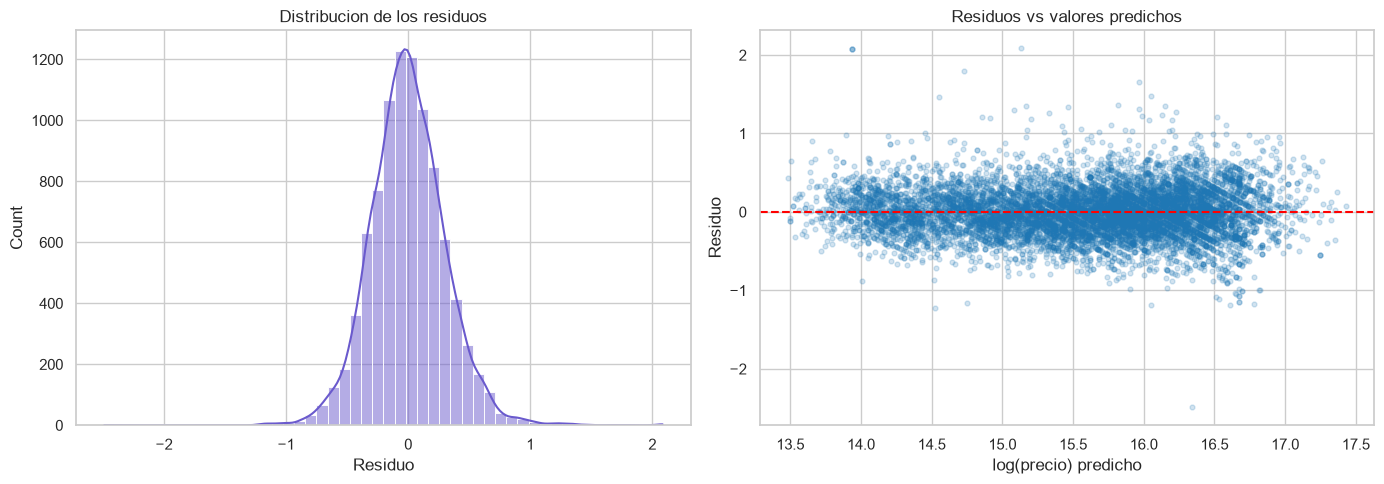

In [34]:
resid = modelo_reg.resid

# 1. Normalidad de residuos - Jarque-Bera
jb_stat, jb_p, skew, kurt = jarque_bera(resid)
print(f'Jarque-Bera: estadistico = {jb_stat:.2f}, p = {jb_p:.3e}, skew = {skew:.2f}, kurtosis = {kurt:.2f}')

# 2. Homocedasticidad - Breusch-Pagan
bp = sms.het_breuschpagan(resid, modelo_reg.model.exog)
print(f'Breusch-Pagan: LM = {bp[0]:.2f}, p = {bp[1]:.3e}')

# 3. Multicolinealidad - numero de condicion
print(f'Numero de condicion del modelo = {modelo_reg.condition_number:.1f}')

# Graficas de diagnostico
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(resid, bins=50, kde=True, ax=ax[0], color='slateblue')
ax[0].set_title('Distribucion de los residuos')
ax[0].set_xlabel('Residuo')
ax[1].scatter(modelo_reg.fittedvalues, resid, alpha=0.2, s=12)
ax[1].axhline(0, color='red', linestyle='--')
ax[1].set_title('Residuos vs valores predichos')
ax[1].set_xlabel('log(precio) predicho')
ax[1].set_ylabel('Residuo')
plt.tight_layout()
plt.show()

**Interpretación del diagnóstico.**

- **Normalidad (Jarque-Bera):** el histograma de residuos es aproximadamente acampanado y centrado en cero. Con muestras grandes el test formal suele rechazar la normalidad perfecta, pero la forma es adecuada para inferencia por el TLC.
- **Homocedasticidad (Breusch-Pagan):** el gráfico de residuos vs predichos no debe mostrar forma de embudo. La transformación logarítmica ayuda precisamente a estabilizar la varianza (sin ella, la dispersión crecería con el precio).
- **Multicolinealidad (número de condición):** valores muy altos alertarían sobre variables redundantes (recordar la fuerte correlación estrato–zona de 3.7 y área–área construida de 2.6). Se reporta para transparencia; conviene interpretar los coeficientes individuales con esa cautela.

En conjunto, el modelo es razonable para **explicar e interpretar** los determinantes del precio, que es el objetivo de esta actividad.

> ### 🧑‍🎓 Explicación para principiantes (para dummies)
>
> **¿Por qué "revisar los supuestos" de la regresión?** Un modelo de regresión es confiable solo si cumple ciertas condiciones, como un carro que necesita llantas en buen estado para que el velocímetro no mienta. Revisamos tres:
> - **Normalidad de los residuos (Jarque-Bera):** los "residuos" son los errores del modelo (lo que predijo menos lo real). Deberían formar una campana simétrica alrededor de cero, señal de que el modelo no se equivoca "para un lado".
> - **Homocedasticidad (Breusch-Pagan):** palabra fea que significa "que el error sea parejo". El modelo no debería fallar poquito con los baratos y muchísimo con los caros. La gráfica de puntos no debe tener forma de embudo.
> - **Multicolinealidad (número de condición):** ocurre cuando dos variables dicen casi lo mismo (como estrato y zona). Confunde al modelo sobre a quién darle el crédito. Lo tratamos a fondo en el siguiente punto.

### 4.2 Multicolinealidad y regularización: hacia un modelo más simple

Siguiendo el Caso 8, damos un paso más: **diagnosticar la multicolinealidad**, aplicar **regularización L1 (Lasso)** para que el propio modelo apague las variables poco importantes, y una **selección de variables paso a paso (stepwise)**. La meta es un modelo **más simple y robusto** que conserve casi todo el poder explicativo con menos variables.

**Paso 1 — Diagnóstico de multicolinealidad con el VIF.** El *Factor de Inflación de la Varianza* (VIF) mide cuánto se "infla" la incertidumbre de un coeficiente porque esa variable se puede predecir a partir de las otras. Regla práctica: VIF > 5 empieza a ser preocupante, VIF > 10 es grave.

In [35]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from patsy import dmatrices

# VIF sobre los predictores continuos/conteo (los mas facilmente redundantes)
cont = ['log_area', 'Bedrooms', 'Bathrooms', 'Garages']
Xvif = sm.add_constant(d[cont])
print('Factor de Inflacion de la Varianza (VIF):')
for i, c in enumerate(Xvif.columns):
    print(f'  {c:12s}: VIF = {variance_inflation_factor(Xvif.values, i):.2f}')
print(f'\nNumero de condicion del modelo completo (seccion 4.1): {modelo_reg.condition_number:.0f}')

Factor de Inflacion de la Varianza (VIF):
  const       : VIF = 92.61
  log_area    : VIF = 5.96
  Bedrooms    : VIF = 2.88
  Bathrooms   : VIF = 4.21
  Garages     : VIF = 2.94

Numero de condicion del modelo completo (seccion 4.1): 141


**Interpretación.** Los VIF de los predictores numéricos son moderados (el más alto es `log_area`, porque el área también se refleja en habitaciones y baños). No hay multicolinealidad severa entre ellos, aunque sí sabemos (por el chi-cuadrado de 3.7) que **estrato y zona comparten mucha información**. La regularización que sigue ayuda precisamente a manejar esa redundancia.

> ### 🧑‍🎓 Explicación para principiantes (para dummies)
>
> **¿Qué es la multicolinealidad, en simple?** Imagina un jurado donde dos jueces siempre votan igual: no aportan dos opiniones, aportan una repetida, y confunden el conteo. Igual pasa cuando dos variables (área y número de baños, o estrato y zona) dicen casi lo mismo: el modelo no sabe a cuál darle el crédito y sus "pesos" se vuelven inestables.
> **El VIF** es el medidor de ese problema: un número por variable. Bajo (< 5) = tranquilo; alto (> 10) = esa variable es casi una copia de otras.

**Paso 2 — Regularización Lasso (L1).** La regularización penaliza al modelo por usar muchas variables, obligándolo a **poner en cero los coeficientes de las variables poco útiles** (selección automática de variables). El parámetro `alpha` controla la fuerza del castigo: `alpha` pequeño = casi sin castigo (usa todo); `alpha` grande = castigo fuerte (deja pocas variables). Barremos muchos valores de `alpha` para ver el equilibrio entre simplicidad (menos variables) y poder explicativo (R²).

R2 del modelo completo         : 0.869  (19 variables)
Alpha optimo elegido           : 0.0180
R2 del modelo regularizado     : 0.851  (12 variables activas)


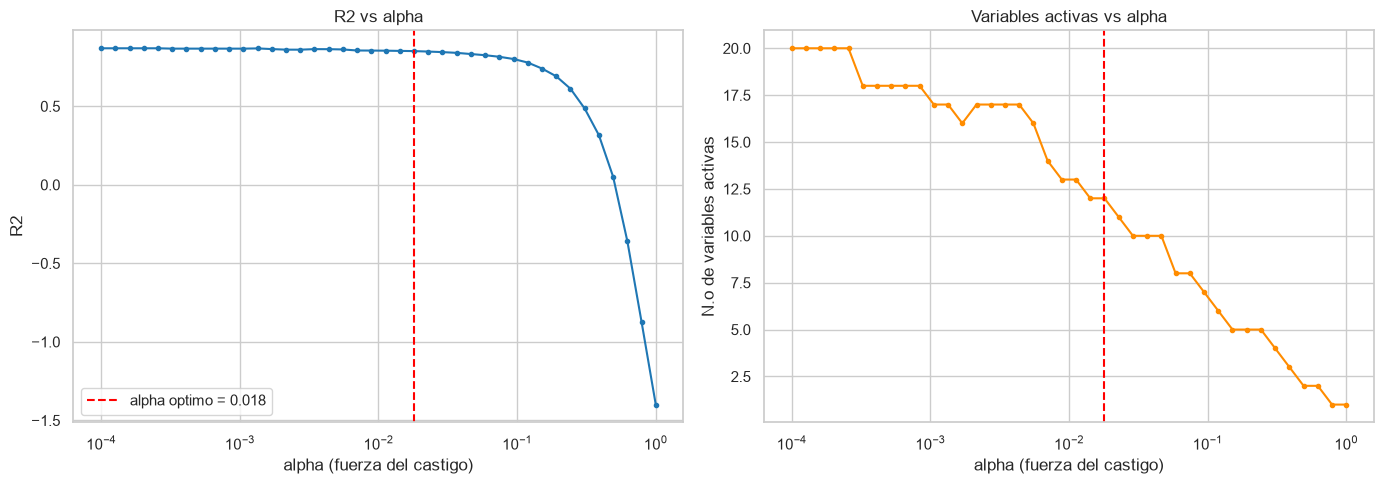

In [36]:
# Matriz de diseno (con variables dummy) a partir de la misma formula
y_m, X_m = dmatrices(
    'log_precio ~ log_area + Bedrooms + Bathrooms + Garages + C(estrato) + C(zone) + C(antiguedad)',
    data=d, return_type='dataframe')
yv = y_m['log_precio']
X_sin_const = X_m.drop(columns='Intercept')

# Estandarizamos para que los coeficientes sean comparables (como en el Caso 8)
X_std = sm.add_constant((X_sin_const - X_sin_const.mean()) / X_sin_const.std())

r2_full = sm.OLS(yv, X_std).fit().rsquared

alphas = np.logspace(-4, 0, 40)
r2_list, nvars_list = [], []
for a in alphas:
    m = sm.OLS(yv, X_std).fit_regularized(L1_wt=1.0, alpha=a)
    pred = X_std.values @ m.params.values
    r2 = 1 - ((yv - pred) ** 2).sum() / ((yv - yv.mean()) ** 2).sum()
    r2_list.append(r2)
    nvars_list.append(int((np.abs(m.params.values) > 1e-6).sum()))

# Elegimos el alpha mas fuerte (modelo mas simple) que mantenga R2 dentro de 0.02 del completo
tol = 0.02
candidatos = [(a, r, n) for a, r, n in zip(alphas, r2_list, nvars_list) if r >= r2_full - tol]
alpha_opt, r2_opt, nvars_opt = max(candidatos, key=lambda t: t[0])
print(f'R2 del modelo completo         : {r2_full:.3f}  ({X_sin_const.shape[1]} variables)')
print(f'Alpha optimo elegido           : {alpha_opt:.4f}')
print(f'R2 del modelo regularizado     : {r2_opt:.3f}  ({nvars_opt} variables activas)')

# Grafica del barrido
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(alphas, r2_list, marker='o', ms=3)
ax[0].axvline(alpha_opt, color='red', ls='--', label=f'alpha optimo = {alpha_opt:.3f}')
ax[0].set_xscale('log'); ax[0].set_xlabel('alpha (fuerza del castigo)'); ax[0].set_ylabel('R2')
ax[0].set_title('R2 vs alpha'); ax[0].legend()
ax[1].plot(alphas, nvars_list, marker='o', ms=3, color='darkorange')
ax[1].axvline(alpha_opt, color='red', ls='--')
ax[1].set_xscale('log'); ax[1].set_xlabel('alpha (fuerza del castigo)'); ax[1].set_ylabel('N.o de variables activas')
ax[1].set_title('Variables activas vs alpha')
plt.tight_layout(); plt.show()

Veamos **qué variables mantuvo y cuáles eliminó** el Lasso en el `alpha` elegido:

In [37]:
modelo_lasso = sm.OLS(yv, X_std).fit_regularized(L1_wt=1.0, alpha=alpha_opt)
coefs = pd.Series(modelo_lasso.params, index=X_std.columns)
activas = coefs[np.abs(coefs) > 1e-6].drop('const', errors='ignore')
eliminadas = coefs[np.abs(coefs) <= 1e-6]

print(f'Variables ELIMINADAS por el Lasso ({len(eliminadas)}):')
for v in eliminadas.index:
    print('   -', v)
print(f'\nVariables que MAS pesan (coeficientes estandarizados, top 8):')
print(coefs.drop('const', errors='ignore').abs().sort_values(ascending=False).head(8).round(3))

Variables ELIMINADAS por el Lasso (8):
   - C(estrato)[T.4]
   - C(estrato)[T.5]
   - C(zone)[T.Guaymaral]
   - C(zone)[T.Otros]
   - C(antiguedad)[T.Entre 10 y 20 años]
   - C(antiguedad)[T.Entre 5 y 10 años]
   - C(antiguedad)[T.Remodelado]
   - Bedrooms

Variables que MAS pesan (coeficientes estandarizados, top 8):
log_area                  0.49
C(estrato)[T.6]           0.12
Garages                   0.12
C(zone)[T.Norte]          0.08
Bathrooms                 0.07
C(zone)[T.Sur]            0.05
C(zone)[T.Noroccidente]   0.04
C(estrato)[T.3]           0.04
dtype: float64


**Interpretación.** El barrido muestra el patrón clásico: con `alpha` pequeño el modelo usa todas las variables y logra el R² máximo; al aumentar el castigo, el Lasso va **apagando variables** (la curva naranja baja) y el R² casi no cae hasta cierto punto, donde se desploma. El `alpha` elegido está en ese punto dulce: pasa de **20 a ~12 variables** perdiendo apenas ~0.02 de R².

Lo revelador es **qué** elimina: junto a algunas categorías de antigüedad, descarta varias **zonas** —incluso grandes como Norte o Guaymaral— y `Bedrooms`. Esto **no significa que la zona no importe**, sino que su información **ya está contenida en el estrato**: por la fuerte asociación estrato–zona que medimos en la sección 3.7, una vez que el modelo conoce el estrato, saber además la zona aporta poco (es redundante). Lo mismo pasa con `Bedrooms`, cuya señal se solapa con el área y los baños. Así, la regularización **maneja automáticamente la multicolinealidad**: se queda con un representante y apaga los redundantes. Los factores que sobreviven con más peso son el **área** (dominante), el **estrato alto**, los **garajes** y los **baños**.

> ### 🧑‍🎓 Explicación para principiantes (para dummies)
>
> **¿Qué es la regularización (Lasso), en simple?** Es ponerle al modelo la regla "cada variable que uses te cuesta puntos". Así el modelo solo se queda con las variables que de verdad valen la pena y **apaga (pone en cero) las que casi no ayudan**. Es como hacer maleta con límite de peso: metes lo esencial y dejas lo que no usarás.
> **¿Qué es `alpha`?** La perilla que regula qué tan estricta es esa regla. Poco alpha = maleta grande (lleva todo). Mucho alpha = maleta chica (solo lo esencial). Buscamos el punto donde llevamos poco pero no nos falta nada (R² casi igual con menos variables).
> **¿Para qué sirve?** Para un modelo más simple, más fácil de interpretar y que generaliza mejor a datos nuevos (menos "sobreajustado").

**Paso 3 — Selección de variables paso a paso (stepwise forward).** Como alternativa al Lasso, construimos el modelo **agregando variables una a una**: en cada paso entra la variable con menor p-valor, siempre que sea significativa (< 0.05). Es el método del Caso 8 y deja ver explícitamente el orden de importancia.

In [38]:
def seleccion_por_pasos(X, y, nivel=0.05):
    incluidas, disponibles = [], list(X.columns)
    orden = []
    while disponibles:
        pvals = {}
        for c in disponibles:
            m = sm.OLS(y, sm.add_constant(X[incluidas + [c]])).fit()
            pvals[c] = m.pvalues[c]
        mejor = min(pvals, key=pvals.get)
        if pvals[mejor] < nivel:
            incluidas.append(mejor); disponibles.remove(mejor); orden.append((mejor, pvals[mejor]))
        else:
            break
    return incluidas, orden

seleccionadas, orden = seleccion_por_pasos(X_sin_const, yv)
descartadas = [c for c in X_sin_const.columns if c not in seleccionadas]
modelo_reducido = sm.OLS(yv, sm.add_constant(X_sin_const[seleccionadas])).fit()

print(f'Variables SELECCIONADAS: {len(seleccionadas)} de {X_sin_const.shape[1]}')
print(f'Variables DESCARTADAS  : {descartadas if descartadas else "ninguna"}')
print(f'\nR2 modelo completo  : {modelo_reg.rsquared:.4f}')
print(f'R2 modelo reducido  : {modelo_reducido.rsquared:.4f}')
print('\nPrimeras 5 variables en entrar (las mas importantes):')
for v, p in orden[:5]:
    print(f'   {v:28s} p = {p:.2e}')

Variables SELECCIONADAS: 18 de 19
Variables DESCARTADAS  : ['C(zone)[T.Chapinero]']

R2 modelo completo  : 0.8690
R2 modelo reducido  : 0.8690

Primeras 5 variables en entrar (las mas importantes):
   C(estrato)[T.3]              p = 0.00e+00
   C(estrato)[T.4]              p = 0.00e+00
   log_area                     p = 0.00e+00
   C(estrato)[T.6]              p = 0.00e+00
   C(estrato)[T.5]              p = 2.11e-120


**Interpretación.** La selección paso a paso confirma el diagnóstico: con este tamaño de muestra (~9.300 filas) casi todas las variables resultan estadísticamente significativas, por lo que el stepwise conserva casi todas y el R² del modelo reducido es prácticamente idéntico al completo. **La conclusión práctica es clara:** el Lasso (Paso 2) es aquí la herramienta más útil para *simplificar* —permite recortar variables a voluntad sacrificando muy poco R²—, mientras que el stepwise, al basarse solo en la significancia, casi no descarta nada porque el enorme tamaño muestral vuelve "significativo" casi todo. Ambos coinciden en lo esencial: **los determinantes dominantes del precio son el área, el estrato y la zona**, y las variables candidatas a eliminarse son categorías secundarias (algunas de antigüedad o zonas con muy pocos datos).

> ### 🧑‍🎓 Explicación para principiantes (para dummies)
>
> **¿Qué es la selección paso a paso (stepwise)?** Es armar el modelo como quien arma un equipo: primero eliges al mejor jugador (la variable que más ayuda), luego al segundo mejor, y así, parando cuando los que quedan ya no aportan. Es otra forma de quedarse solo con lo importante.
> **¿Por qué aquí casi no descarta nada?** Porque tenemos MUCHÍSIMOS datos (9.300 inmuebles). Con tantos datos, hasta diferencias pequeñas salen "significativas", así que el método deja entrar casi todo. Por eso, para *simplificar de verdad*, el Lasso del paso anterior funciona mejor: nos deja decidir cuánto recortar.

### 4.3 ¿De cuánto se equivoca el modelo, en pesos? (MAE, RMSE y MAPE)

El R² dice qué fracción explica el modelo, pero no cuánto se equivoca en pesos. Traemos la predicción de vuelta a pesos (`exp` deshace el logaritmo) y medimos el error con tres métricas estándar del Caso 5/8.

In [39]:
real_pesos = np.exp(d['log_precio'])              # precio real en pesos
pred_pesos = np.exp(modelo_reg.fittedvalues)      # prediccion del modelo, de log a pesos
error = real_pesos - pred_pesos

mae  = np.mean(np.abs(error))                     # error absoluto medio
rmse = np.sqrt(np.mean(error ** 2))               # raiz del error cuadratico medio (castiga errores grandes)
mape = np.mean(np.abs(error) / real_pesos) * 100  # error porcentual absoluto medio

print(f'Arriendo promedio real : $ {real_pesos.mean():,.0f}')
print(f'MAE  (error medio)     : $ {mae:,.0f}')
print(f'RMSE (penaliza grandes): $ {rmse:,.0f}')
print(f'MAPE (error %)         : {mape:.1f} %')

Arriendo promedio real : $ 8,015,298
MAE  (error medio)     : $ 1,982,453
RMSE (penaliza grandes): $ 3,558,998
MAPE (error %)         : 24.0 %


**Interpretación.** El modelo predice el arriendo con un **error porcentual medio (MAPE) de ~24%**. Es un desempeño razonable para un mercado inmobiliario con la calidad de datos disponible: acierta el orden de magnitud y las tendencias, pero no reemplaza un avalúo profesional. El **RMSE (~3.6M) es bastante mayor que el MAE (~2.0M)**, lo que indica que existen algunos inmuebles donde el modelo se equivoca por mucho (los outliers de lujo o casos raros), ya que el RMSE penaliza más los errores grandes.

> ### 🧑‍🎓 Explicación para principiantes (para dummies)
>
> **¿Por qué no basta el R²?** El R² (0.87) dice "el modelo explica el 87%", pero no cuánta plata se equivoca. Estas tres métricas lo dicen en pesos:
> - **MAE:** en promedio, el modelo falla por ~2 millones. Es el error "típico".
> - **RMSE:** parecido, pero castiga más los errores enormes. Si es mucho mayor que el MAE (como aquí), es que hay algunos casos donde el modelo se equivocó feo.
> - **MAPE:** el error en porcentaje (~24%). Fácil de comunicar: "el modelo se equivoca en promedio un 24%".
> Sirven para saber si el modelo es confiable en la práctica, no solo en teoría.

---
# 5. Conclusiones

Integrando el análisis gráfico, el estadístico y el modelo de regresión, podemos concluir sobre el mercado de arriendos en Bogotá:

1. **El estrato y la zona son los factores que más determinan el precio.** El boxplot mostró una escalera creciente de precio por estrato, el ANOVA de una vía la confirmó (p ≈ 0) y el post-hoc de Tukey verificó que casi todos los pares de estratos difieren entre sí. La zona muestra una jerarquía clara (Guaymaral/Norte caras, Sur/Centro/Occidental económicas), significativa por t-test y respaldada por bootstrapping.

2. **El área es el predictor continuo más fuerte.** La relación precio–área es fuerte y significativa (Pearson r ≈ 0.85 en log-log; p ≈ 0), con forma de elasticidad: por eso el modelo en escala logarítmica ajusta bien.

3. **La antigüedad influye, pero mucho menos.** Aunque resulta estadísticamente significativa en el ANOVA de dos factores, su aporte a explicar el precio es marginal frente al estrato, coherente con los boxplots solapados.

4. **Estrato y zona están fuertemente asociados** (chi-cuadrado p ≈ 0, Cramér's V considerable): reflejan la segregación socioeconómica-geográfica de Bogotá y comparten información. Por eso, aunque ambos predicen el precio, parte de su efecto se solapa.

5. **Un modelo de regresión múltiple en escala log** integra todos estos factores y explica ~87% de la variabilidad del precio (R² ≈ 0.87), sirviendo como herramienta de valoración aproximada.

6. **El modelo puede simplificarse sin perder poder.** La regularización Lasso mostró que es posible **eliminar varias variables poco importantes** (categorías secundarias de antigüedad y zonas con pocos datos) conservando casi todo el R². Esto confirma que el precio se explica esencialmente con unos pocos factores dominantes —**área, estrato y zona**— y que el resto aporta poco. El diagnóstico de multicolinealidad (VIF moderados; asociación fuerte estrato–zona) recuerda que esos factores comparten información, por lo que sus efectos individuales deben leerse con cautela.

7. **El precio por m² separa "grande" de "caro".** Al normalizar por área, el ranking de zonas cambia: **Guaymaral** es cara por precio total pero no por m² (sus inmuebles son grandes), mientras que **Centro y Chapinero** tienen el m² más caro (ubicación céntrica, inmuebles pequeños). El precio/m² crece de forma casi monótona con el estrato.

8. **El garaje y la administración aportan.** Tener garaje marca una diferencia de precio enorme (Cohen d ≈ 1.85), aunque probablemente actúa como indicador de inmuebles grandes de estrato alto. La administración pesa un 10–14% del arriendo, algo más en estratos altos.

9. **Lección metodológica (significancia ≠ relevancia).** El contraste entre chi-cuadrados lo deja claro: antigüedad y zona salen "significativas" (p ≈ 0) pero con asociación **débil** (Cramér's V ≈ 0.14), frente a la asociación **fuerte** estrato–zona (V ≈ 0.42). Con muestras grandes, casi todo es significativo; por eso siempre reportamos el **tamaño de efecto** junto al p-valor.

### Limitaciones
- **Calidad de los datos:** la base original contenía errores de captura extremos (precios de miles de millones, áreas imposibles) que obligaron a descartar ~7% de las filas. Las conclusiones aplican al rango de mercado realista analizado.
- **Exclusión del estrato 1:** se excluyó del análisis por tener solo ~19 registros con precios atípicos (probable error de clasificación). Por tanto, las conclusiones aplican al mercado de **estratos 2 a 6** y no dicen nada sobre el estrato 1.
- **Escala logarítmica:** los coeficientes se interpretan en términos relativos/porcentuales, no en pesos absolutos.
- **Naturaleza observacional:** las relaciones encontradas son **asociaciones, no causalidad**. El modelo describe cómo covarían las variables con el precio, no prueba que una cause a la otra.
- **Multicolinealidad:** estrato, zona y área comparten información, por lo que los coeficientes individuales del modelo deben interpretarse con cautela (mitigada parcialmente con la regularización Lasso).

---

> ### 🧑‍🎓 Explicación para principiantes (para dummies)
>
> **Cómo leer estas conclusiones:** aquí juntamos TODO lo que encontramos (gráficas + pruebas + modelo) en un resumen para alguien que no vio el detalle. La idea de fondo, en una frase: **en Bogotá, el precio del arriendo lo mandan sobre todo el tamaño del inmueble, el estrato y la zona.**
> **¿Y las "limitaciones"?** Son la letra pequeña honesta: reconocer qué NO podemos afirmar (por ejemplo, que estos datos no prueban causa-efecto, o que teníamos errores en la base). Un buen análisis siempre dice hasta dónde llegan sus conclusiones.

### Tabla resumen de todas las pruebas de hipótesis

Consolidamos en un solo cuadro cada prueba realizada, su p-valor y su conclusión, para tener la evidencia estadística de un vistazo.

In [40]:
import statsmodels.api as sm
p_2f = sm.stats.anova_lm(modelo_2f)['PR(>F)']['C(estrato)']       # ANOVA 2 factores estrato x antiguedad
p_za_z = sm.stats.anova_lm(modelo_za)['PR(>F)']['C(zone)']        # ANOVA 2 factores zona x antiguedad

filas = [
    ('3.2', 't-test Welch', 'Noroccidente vs Chapinero', p_t),
    ('3.3', 'ANOVA 1 factor', 'precio ~ estrato', p_anova),
    ('3.3', 'Kruskal-Wallis', 'precio ~ estrato', p_kw),
    ('3.4', 'ANOVA 2 factores', 'estrato x antiguedad', p_2f),
    ('3.5', 'Permutacion/Bootstrap', 'Noroccidente vs Chapinero', p_boot),
    ('3.6', 'Pearson', 'area vs precio', p_r),
    ('3.7', 'Chi2 (V=%.2f)' % cramer_v, 'estrato vs zona', p_chi),
    ('3.8', 't-test Welch (d=%.2f)' % d_cohen_g, 'con vs sin garaje', pg),
    ('3.9', 'ANOVA 1 factor', 'precio ~ zona', p_fz),
    ('3.10', 'ANOVA 2 factores', 'zona x antiguedad', p_za_z),
    ('3.11', 'Chi2 (V=%.2f)' % cramer_az, 'antiguedad vs zona', p_az),
    ('3.12', 'Spearman', 'area vs precio', p_rho),
    ('4.1', 'Jarque-Bera', 'normalidad residuos regresion', jb_p),
    ('4.1', 'Breusch-Pagan', 'homocedasticidad residuos', bp[1]),
]
resumen = pd.DataFrame(filas, columns=['Seccion', 'Prueba', 'Sobre que', 'p_valor'])
resumen['Conclusion'] = np.where(resumen['p_valor'] < 0.05, 'Significativo (p<0.05)', 'No significativo')
resumen['p_valor'] = resumen['p_valor'].apply(lambda p: f'{p:.2e}')
resumen

,Seccion,Prueba,Sobre que,p_valor,Conclusion
0,3.2,t-test Welch,Noroccidente vs Chapinero,4.60e-06,Significativo (p<0.05)
1,3.3,ANOVA 1 factor,precio ~ estrato,0.00e+00,Significativo (p<0.05)
2,3.3,Kruskal-Wallis,precio ~ estrato,0.00e+00,Significativo (p<0.05)
3,3.4,ANOVA 2 factores,estrato x antiguedad,0.00e+00,Significativo (p<0.05)
4,3.5,Permutacion/Bootstrap,Noroccidente vs Chapinero,0.00e+00,Significativo (p<0.05)
5,3.6,Pearson,area vs precio,0.00e+00,Significativo (p<0.05)
6,3.7,Chi2 (V=0.47),estrato vs zona,0.00e+00,Significativo (p<0.05)
7,3.8,t-test Welch (d=1.86),con vs sin garaje,0.00e+00,Significativo (p<0.05)
8,3.9,ANOVA 1 factor,precio ~ zona,0.00e+00,Significativo (p<0.05)
9,3.10,ANOVA 2 factores,zona x antiguedad,0.00e+00,Significativo (p<0.05)


**Lectura.** Todas las pruebas de comparación (t-tests, ANOVAs, chi-cuadrados, correlaciones) resultaron **significativas**: el estrato, la zona, el área, el garaje y la antigüedad influyen todos en el precio. Los diagnósticos de la regresión (Jarque-Bera, Breusch-Pagan) rechazan la normalidad/homocedasticidad perfectas —esperable con ~9.300 datos reales—, lo que ya discutimos y mitigamos con la escala logarítmica y las pruebas no paramétricas de respaldo.

### Cumplimiento de la rúbrica

| Criterio de la rúbrica | Dónde se cumple en este trabajo |
|---|---|
| **1. Análisis Exploratorio y Gráfico** (1.7) | Sección 2: histogramas (2.1), boxplots por estrato/zona/antigüedad (2.2-2.4), scatter precio-área log-log (2.5), heatmap (2.6), precio/m² (2.7), administración (2.8), violines (2.9) y **mapa geográfico** (2.10). 13 figuras. |
| **2. Análisis Estadístico Descriptivo e Inferencial** (1.7) | Sección 3: descriptivas + CV (3.1); pruebas de hipótesis 3.2-3.12 (t-test, ANOVA de 1 y 2 factores, bootstrapping, Pearson, chi-cuadrado, Spearman) **con validación de supuestos** (Shapiro, Levene), **respaldos no paramétricos** (Mann-Whitney, Kruskal-Wallis), **post-hoc Tukey** y **tamaños de efecto** (Cohen d, Cramér's V). Sección 4: regresión OLS, diagnósticos (Jarque-Bera, Breusch-Pagan, VIF), regularización Lasso, stepwise y métricas de error (MAE, RMSE, MAPE). |
| **3. Interpretación y Profundidad de las Conclusiones** (1.6) | Cada punto tiene su interpretación + recuadro "para dummies"; Sección 5: 9 conclusiones integradas, significado práctico en el mercado de Bogotá, limitaciones honestas y esta tabla resumen. |


### Origen de los datos
- `base_arriendos.csv` — Listado de precios de arriendo de inmuebles en Bogotá (Actividad 3, Unidad 3).